In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import chart_studio
from chart_studio.plotly import plot, iplot

from urllib.request import urlopen
import json
from IPython.display import Image

import plotly.io as pio
import plotly.express as px     
import plotly.graph_objects as go 
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
from plotly.validators.scatter.marker import SymbolValidator

import geopandas as gpd

from mapboxgl.viz import *      
from mapboxgl.utils import create_color_stops, create_radius_stops, create_weight_stops, create_numeric_stops, df_to_geojson
from mapboxgl.viz import ImageViz
from matplotlib import cm
from mapboxgl.viz import RasterTilesViz

import mapclassify as mc 

In [2]:
# 한글폰트 설정
plt.rc("font", family="AppleGothic")

%config InlineBackend.figure_format = 'retina'
sns.set(font="AppleGothic", 
        rc={"axes.unicode_minus":False},
        style='darkgrid')

pd.options.display.float_format = '{:20.3f}'.format

pd.set_option('display.max_rows', 50)

# pd.set_option('display.max_rows', None)
# pd.options.display.max_rows = 60

# 01. Data Preprocessing

## 01.1. csv 변환

In [3]:
#10grid
# SHP 파일들이 있는 폴더 경로
input_folder = '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/raw/shp/10grid' 
output_folder = '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/raw/csv'

# 출력 폴더가 없다면 생성
os.makedirs(output_folder, exist_ok=True)

# 폴더 내 모든 shp 파일에 대해 반복
for filename in os.listdir(input_folder):
    if filename.endswith(".shp"):
        file_path = os.path.join(input_folder, filename)
        
        try:
            # SHP 파일 읽기
            gdf = gpd.read_file(file_path)

            # .shp → .csv 파일명 변환
            csv_filename = filename.replace('.shp', '.csv')
            csv_path = os.path.join(output_folder, csv_filename)

            # GeoDataFrame을 CSV로 저장 (geometry는 WKT로 자동 변환됨)
            gdf.to_csv(csv_path, index=False, encoding='utf-8-sig')
            
            print(f"✅ Saved: {csv_path}")
        except Exception as e:
            print(f"❌ Error processing {filename}: {e}")

✅ Saved: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/csv/final_SCI_grid(10)_하천거리.csv
✅ Saved: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/csv/SCI_grid(10)_하수관로.csv
✅ Saved: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/csv/SCI_grid(10)_맨홀개수.csv
✅ Saved: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/csv/final_SCI_grid(10)_홍수흔적도.csv
✅ Saved: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper

In [3]:
#30grid
# SHP 파일들이 있는 폴더 경로
input_folder = '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/raw/shp/30grid' 
output_folder = '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/raw/csv'

# 출력 폴더가 없다면 생성
os.makedirs(output_folder, exist_ok=True)

# 폴더 내 모든 shp 파일에 대해 반복
for filename in os.listdir(input_folder):
    if filename.endswith(".shp"):
        file_path = os.path.join(input_folder, filename)
        
        try:
            # SHP 파일 읽기
            gdf = gpd.read_file(file_path)

            # .shp → .csv 파일명 변환
            csv_filename = filename.replace('.shp', '.csv')
            csv_path = os.path.join(output_folder, csv_filename)

            # GeoDataFrame을 CSV로 저장 (geometry는 WKT로 자동 변환됨)
            gdf.to_csv(csv_path, index=False, encoding='utf-8-sig')
            
            print(f"✅ Saved: {csv_path}")
        except Exception as e:
            print(f"❌ Error processing {filename}: {e}")

✅ Saved: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/csv/SCI_grid(30)_불투수면적.csv
✅ Saved: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/csv/SCI_grid(30)_고도.csv
✅ Saved: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/csv/SCI_grid(30)_하천거리.csv
✅ Saved: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/csv/SCI_grid(30)_토양배수등급2.csv
✅ Saved: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Pap

In [5]:
# 100grid
# SHP 파일들이 있는 폴더 경로
input_folder = '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/raw/shp/100grid' 
output_folder = '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/raw/csv'
# 출력 폴더가 없다면 생성
os.makedirs(output_folder, exist_ok=True)

# 폴더 내 모든 shp 파일에 대해 반복
for filename in os.listdir(input_folder):
    if filename.endswith(".shp"):
        file_path = os.path.join(input_folder, filename)
        
        try:
            # SHP 파일 읽기
            gdf = gpd.read_file(file_path)

            # .shp → .csv 파일명 변환
            csv_filename = filename.replace('.shp', '.csv')
            csv_path = os.path.join(output_folder, csv_filename)

            # GeoDataFrame을 CSV로 저장 (geometry는 WKT로 자동 변환됨)
            gdf.to_csv(csv_path, index=False, encoding='utf-8-sig')
            
            print(f"✅ Saved: {csv_path}")
        except Exception as e:
            print(f"❌ Error processing {filename}: {e}")

✅ Saved: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/csv/SCI_grid(100)_홍수흔적도.csv
✅ Saved: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/csv/SCI_grid(100)_하수관로.csv
✅ Saved: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/csv/SCI_grid(100)_토양배수등급.csv
✅ Saved: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/csv/SCI_grid(100)_고도.csv
✅ Saved: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For 

## 01.2. 데이터 통합

### 10grid

In [21]:
# 10grid

# 1. 기준 fid 전체 목록 생성 (1 ~ 2532578)
fid_full = pd.DataFrame({'fid': range(1, 2532579)})

# 2. 파일 경로 설정
base_path = '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/raw/csv/'

# 3. 각 데이터 불러오고 fid 기준 평균 집계
def load_and_aggregate(filename, value_col):
    df = pd.read_csv(base_path + filename)[['fid', value_col]]
    df_agg = df.groupby('fid', as_index=False)[value_col].mean()
    return df_agg

# 4. 개별 데이터 불러오기
flood_trace_data = load_and_aggregate('final_SCI_grid(10)_홍수흔적도.csv', 'dept_avg')
sewer_length_data = load_and_aggregate('SCI_grid(10)_하수관로.csv', 'length_sew')
soil_drainage_data = load_and_aggregate('final_SCI_grid(10)_토양배수등급.csv', 'drainscore')
impermeable_area_data = load_and_aggregate('final_SCI_grid(10)_불투수면적.csv', 'Permeable')
height_data = load_and_aggregate('final_SCI_grid(10)_고도.csv', 'height')
slope_data = load_and_aggregate('slope.csv', 'slope_avg')
manhole_data = load_and_aggregate('SCI_grid(10)_맨홀개수.csv', 'NUMPOINTS')
river_distance_data = load_and_aggregate('final_SCI_grid(10)_하천거리.csv', 'distance_a')
reservoir_distance_data = load_and_aggregate('SCI_gird(10)_저수지거리.csv', 'river_dist')

# 5. 병합 수행 (outer join으로 누락값 유지)
merged_data = fid_full.merge(flood_trace_data, on='fid', how='left') \
                      .merge(sewer_length_data, on='fid', how='left') \
                      .merge(soil_drainage_data, on='fid', how='left') \
                      .merge(impermeable_area_data, on='fid', how='left') \
                      .merge(height_data, on='fid', how='left') \
                      .merge(slope_data, on='fid', how='left') \
                      .merge(manhole_data, on='fid', how='left') \
                      .merge(river_distance_data, on='fid', how='left') \
                      .merge(reservoir_distance_data, on='fid', how='left')

# 6. 누락값(NaN) → 0으로 대체
merged_data.fillna(0, inplace=True)

# 7. 정렬 (선택적 – 이미 정렬돼 있을 가능성 높음)
merged_data.sort_values(by='fid', inplace=True)
merged_data.reset_index(drop=True, inplace=True)

# 8. 저장
output_path = '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/processed/10grid/SCI_flood_risk_data_filterd.csv'
merged_data.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ 병합 완료 및 저장됨: {output_path}")

✅ 병합 완료 및 저장됨: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/csv/SCI_flood_risk_data_filterd.csv


In [22]:
merged_data

,fid,dept_avg,length_sew,drainscore,Permeable,height,slope_avg,NUMPOINTS,distance_a,river_dist
0,1,0.000,0.000,4.000,0.000,6.500,1.000,0.000,384.624,737.346
1,2,0.000,0.000,4.000,0.000,7.000,1.000,0.000,380.640,739.739
2,3,0.000,0.000,4.000,0.000,7.000,1.000,0.000,374.142,742.259
3,4,0.000,0.000,4.000,0.000,7.000,1.000,0.000,367.802,744.905
4,5,0.000,0.000,4.000,0.000,7.000,1.000,0.000,361.627,747.675
...,...,...,...,...,...,...,...,...,...,...
2532573,2532574,0.000,0.000,4.000,0.000,30.000,3.500,0.000,869.973,542.285
2532574,2532575,0.000,0.000,4.000,0.500,26.000,0.000,0.000,835.300,734.353
2532575,2532576,0.000,5.000,4.000,0.750,30.000,3.000,1.000,873.505,561.331
2532576,2532577,0.000,4.000,4.000,0.000,30.000,3.000,0.000,876.440,556.031


In [31]:

df = pd.read_csv('/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/processed/10grid/SCI_flood_risk_data_filterd.csv')

# 컬럼명 변경: {'기존명': '새이름'}
df.rename(columns={
    'Permeable': 'permeable',
    'NUMPOINTS': 'numpoints',
    'distance_a':'distance_avg',
    'river_dist':'river_distance_avg',
    'drainscore':'drainscore_avg'
}, inplace=True)

# 저장
df.to_csv('/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/processed/10grid/SCI_flood_risk_data_cleand.csv', index=False, encoding='utf-8-sig')

In [34]:


# 1. 병합 대상 데이터 불러오기
df = pd.read_csv('/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/processed/10grid/SCI_flood_risk_data_cleand.csv')

# 2. ADM 정보 불러오기 (fid, ADM_CD, ADM_NM)
soil_drainage = pd.read_csv(base_path + 'csv/final_SCI_grid(10)_토양배수등급.csv')[['fid', 'ADM_CD', 'ADM_NM']]

# 3. 중복된 fid에 대해 대표값(첫 번째 값)만 남기기
adm_cleaned = soil_drainage.groupby('fid', as_index=False).agg({
    'ADM_CD': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'ADM_NM': lambda x: x.mode().iloc[0] if not x.mode().empty else None
})

# 4. 병합 (정제된 adm_cleaned를 사용)
df = df.merge(adm_cleaned, on='fid', how='left')


# 6. 중복 제거 검증 (선택적으로 확인)
duplicate_fids = df[df.duplicated(subset='fid', keep=False)]
print(f"중복 fid 개수: {duplicate_fids['fid'].nunique()}")

# 7. 저장
output_path = '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/processed/10grid/SCI_flood_risk_data_ADM.csv'
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ 저장 완료: {output_path}")

중복 fid 개수: 0
✅ 저장 완료: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/SCI_flood_risk_data_ADM.csv


In [35]:
df

,fid,dept_avg,length_sew,drainscore_avg,permeable,height,slope_avg,numpoints,distance_avg,river_distance_avg,ADM_CD,ADM_NM
0,1,0.000,0.000,4.000,0.000,6.500,1.000,0.000,384.624,737.346,39010510.000,일도1동
1,2,0.000,0.000,4.000,0.000,7.000,1.000,0.000,380.640,739.739,39010510.000,일도1동
2,3,0.000,0.000,4.000,0.000,7.000,1.000,0.000,374.142,742.259,39010510.000,일도1동
3,4,0.000,0.000,4.000,0.000,7.000,1.000,0.000,367.802,744.905,39010510.000,일도1동
4,5,0.000,0.000,4.000,0.000,7.000,1.000,0.000,361.627,747.675,39010510.000,일도1동
...,...,...,...,...,...,...,...,...,...,...,...,...
2532573,2532574,0.000,0.000,4.000,0.000,30.000,3.500,0.000,869.973,542.285,39010690.000,도두동
2532574,2532575,0.000,0.000,4.000,0.500,26.000,0.000,0.000,835.300,734.353,39010690.000,도두동
2532575,2532576,0.000,5.000,4.000,0.750,30.000,3.000,1.000,873.505,561.331,39010690.000,도두동
2532576,2532577,0.000,4.000,4.000,0.000,30.000,3.000,0.000,876.440,556.031,39010690.000,도두동


In [29]:
dupes = soil_drainage.groupby('fid')[['ADM_CD', 'ADM_NM']].nunique()
dupes_filtered = dupes[dupes.ADM_CD > 1]  # 다중 행정구역 포함 fid
print(f"중복되는 fid 개수: {len(dupes_filtered)}")

중복되는 fid 개수: 22


In [ ]:
base_path = '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/processed/'

In [36]:
# 토양배수 등급 이진화

# 1. CSV 불러오기
df_cleaned = pd.read_csv(base_path +'10grid/SCI_flood_risk_data_cleand.csv')
df_adm     = pd.read_csv(base_path +'10grid/SCI_flood_risk_data_ADM.csv')

# 2. 이진화가 필요한 컬럼 리스트 지정
cols_to_binarize = ['permeable']  # 필요에 따라 추가/제거

# 3. 결측값(NaN)을 우선 0으로 채움 (없다면 생략 가능)
for df in [df_cleaned, df_adm]:
    for col in cols_to_binarize:
        if col in df.columns:
            df[col] = df[col].fillna(0)

# 4. 0보다 큰 값을 1로 변환 (이진화)
for df in [df_cleaned, df_adm]:
    for col in cols_to_binarize:
        if col in df.columns:
            df[col] = (df[col] > 0).astype(int)

# 5. 저장
df_cleaned.to_csv(base_path +'SCI_flood_risk_data_cleand_binarized.csv', index=False, encoding='utf-8-sig')
df_adm.to_csv(base_path +'SCI_flood_risk_data_ADM_binarized.csv', index=False, encoding='utf-8-sig')

print("✅ 토양배수등급 이진화 및 저장 완료")


✅ 이진화 및 저장 완료


### 30grid

In [17]:
# 30grid

# 1. 기준 fid 전체 목록 생성 (1 ~ 276659)
fid_full = pd.DataFrame({'fid': range(1, 276659)})

# 2. 파일 경로 설정
base_path = '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/raw/csv'

# 3. 각 데이터 불러오고 fid 기준 평균 집계
def load_and_aggregate(filename, value_col):
    df = pd.read_csv(base_path + filename)[['fid', value_col]]
    df_agg = df.groupby('fid', as_index=False)[value_col].mean()
    return df_agg

# 4. 개별 데이터 불러오기
flood_trace_data = load_and_aggregate('SCI_grid(30)_홍수흔적도.csv', 'dept_avg')
sewer_length_data = load_and_aggregate('SCI_grid(30)_하수관로.csv', 'length_sew')
soil_drainage_data = load_and_aggregate('SCI_grid(30)_토양배수등급2.csv', 'drainscore')
impermeable_area_data = load_and_aggregate('SCI_grid(30)_불투수면적.csv', 'permeable')
height_data = load_and_aggregate('SCI_grid(30)_고도.csv', 'height')
slope_data = load_and_aggregate('SCI_grid(30)_토양경사도.csv', 'slope_avg')
manhole_data = load_and_aggregate('SCI_grid(30)_맨홀개수.csv', 'numpoints')
river_distance_data = load_and_aggregate('SCI_grid(30)_하천거리.csv', 'distance_a')
reservoir_distance_data = load_and_aggregate('SCI_gird(30)_저수지거리.csv', 'river_dist')

# 5. 병합 수행 (outer join으로 누락값 유지)
merged_data = fid_full.merge(flood_trace_data, on='fid', how='left') \
                      .merge(sewer_length_data, on='fid', how='left') \
                      .merge(soil_drainage_data, on='fid', how='left') \
                      .merge(impermeable_area_data, on='fid', how='left') \
                      .merge(height_data, on='fid', how='left') \
                      .merge(slope_data, on='fid', how='left') \
                      .merge(manhole_data, on='fid', how='left') \
                      .merge(river_distance_data, on='fid', how='left') \
                      .merge(reservoir_distance_data, on='fid', how='left')

# 6. 누락값(NaN) → 0으로 대체
merged_data.fillna(0, inplace=True)

# 7. 정렬 (선택적 – 이미 정렬돼 있을 가능성 높음)
merged_data.sort_values(by='fid', inplace=True)
merged_data.reset_index(drop=True, inplace=True)

# 8. 저장
output_path = '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/processed/30grid/SCI_30grid_flood_risk_data_filterd.csv'
merged_data.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ 병합 완료 및 저장됨: {output_path}")

✅ 병합 완료 및 저장됨: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/csv/SCI_30grid_flood_risk_data_filterd.csv


In [18]:
merged_data

,fid,dept_avg,length_sew,drainscore,permeable,height,slope_avg,numpoints,distance_a,river_dist
0,1,0.000,0.000,4.000,0.000,7.000,1.000,0.000,351.000,713.000
1,2,0.000,0.000,4.000,0.000,7.000,1.000,0.000,332.000,722.000
2,3,0.000,15.333,4.000,0.000,8.000,1.000,0.000,314.000,732.000
3,4,0.000,12.333,4.000,0.000,9.000,1.000,1.000,298.000,743.000
4,5,0.000,30.000,4.000,0.000,7.000,1.000,0.000,322.000,684.000
...,...,...,...,...,...,...,...,...,...,...
276653,276654,0.000,12.000,4.000,0.111,28.000,1.000,1.000,809.000,594.000
276654,276655,0.000,19.000,4.000,0.300,28.000,2.000,2.000,815.000,574.000
276655,276656,0.000,0.000,4.000,0.389,28.000,3.000,0.000,822.000,555.000
276656,276657,0.000,0.000,4.000,0.625,29.000,3.000,0.000,830.000,537.000


In [20]:

df = pd.read_csv('/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/processed/30grid/SCI_30grid_flood_risk_data_filterd.csv')

# 컬럼명 변경: {'기존명': '새이름'}
df.rename(columns={
    'distance_a':'distance_avg',
    'river_dist':'river_distance_avg',
    'drainscore':'drainscore_avg'
}, inplace=True)

# 저장
df.to_csv('/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/processed/30grid/SCI_30grid_flood_risk_data_cleand.csv', index=False, encoding='utf-8-sig')

In [21]:
df

,fid,dept_avg,length_sew,drainscore_avg,permeable,height,slope_avg,numpoints,distance_avg,river_distance_avg
0,1,0.000,0.000,4.000,0.000,7.000,1.000,0.000,351.000,713.000
1,2,0.000,0.000,4.000,0.000,7.000,1.000,0.000,332.000,722.000
2,3,0.000,15.333,4.000,0.000,8.000,1.000,0.000,314.000,732.000
3,4,0.000,12.333,4.000,0.000,9.000,1.000,1.000,298.000,743.000
4,5,0.000,30.000,4.000,0.000,7.000,1.000,0.000,322.000,684.000
...,...,...,...,...,...,...,...,...,...,...
276653,276654,0.000,12.000,4.000,0.111,28.000,1.000,1.000,809.000,594.000
276654,276655,0.000,19.000,4.000,0.300,28.000,2.000,2.000,815.000,574.000
276655,276656,0.000,0.000,4.000,0.389,28.000,3.000,0.000,822.000,555.000
276656,276657,0.000,0.000,4.000,0.625,29.000,3.000,0.000,830.000,537.000


In [26]:

# 파일 경로 설정
base_path = '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/processed'

# 1. 병합 대상 데이터 불러오기
df = pd.read_csv(base_path + '30grid/SCI_30grid_flood_risk_data_cleand.csv')

# 2. ADM 정보 불러오기 (fid, ADM_CD, ADM_NM)
ADM_data = pd.read_csv(base_path + 'csv/SCI_grid(30)_ADM.csv')[['fid', 'ADM_CD', 'ADM_NM']]

# 3. 중복된 fid에 대해 대표값(첫 번째 값)만 남기기
adm_cleaned = ADM_data.groupby('fid', as_index=False).agg({
    'ADM_CD': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'ADM_NM': lambda x: x.mode().iloc[0] if not x.mode().empty else None
})

# 4. 병합 (정제된 adm_cleaned를 사용)
df = df.merge(adm_cleaned, on='fid', how='left')


# 6. 중복 제거 검증 (선택적으로 확인)
duplicate_fids = df[df.duplicated(subset='fid', keep=False)]
print(f"중복 fid 개수: {duplicate_fids['fid'].nunique()}")

# 7. 저장
output_path = base_path + '30grid/SCI_30grid_flood_risk_data_ADM.csv'
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ 저장 완료: {output_path}")

중복 fid 개수: 0
✅ 저장 완료: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/30grid/SCI_30grid_flood_risk_data_ADM.csv


In [27]:
df

,fid,dept_avg,length_sew,drainscore_avg,permeable,height,slope_avg,numpoints,distance_avg,river_distance_avg,ADM_CD,ADM_NM
0,1,0.000,0.000,4.000,0.000,7.000,1.000,0.000,351.000,713.000,39010510,일도1동
1,2,0.000,0.000,4.000,0.000,7.000,1.000,0.000,332.000,722.000,39010510,일도1동
2,3,0.000,15.333,4.000,0.000,8.000,1.000,0.000,314.000,732.000,39010510,일도1동
3,4,0.000,12.333,4.000,0.000,9.000,1.000,1.000,298.000,743.000,39010510,일도1동
4,5,0.000,30.000,4.000,0.000,7.000,1.000,0.000,322.000,684.000,39010510,일도1동
...,...,...,...,...,...,...,...,...,...,...,...,...
276653,276654,0.000,12.000,4.000,0.111,28.000,1.000,1.000,809.000,594.000,39010690,도두동
276654,276655,0.000,19.000,4.000,0.300,28.000,2.000,2.000,815.000,574.000,39010690,도두동
276655,276656,0.000,0.000,4.000,0.389,28.000,3.000,0.000,822.000,555.000,39010690,도두동
276656,276657,0.000,0.000,4.000,0.625,29.000,3.000,0.000,830.000,537.000,39010690,도두동


In [6]:
# 토양배수 등급 이진화

# 1. CSV 불러오기
df_cleaned = pd.read_csv(base_path +'30grid/SCI_30grid_flood_risk_data_cleand.csv')
df_adm     = pd.read_csv(base_path +'30grid/SCI_30grid_flood_risk_data_ADM.csv')

# 2. 이진화가 필요한 컬럼 리스트 지정
cols_to_binarize = ['permeable']  # 필요에 따라 추가/제거

# 3. 결측값(NaN)을 우선 0으로 채움 (없다면 생략 가능)
for df in [df_cleaned, df_adm]:
    for col in cols_to_binarize:
        if col in df.columns:
            df[col] = df[col].fillna(0)

# 4. 0보다 큰 값을 1로 변환 (이진화)
for df in [df_cleaned, df_adm]:
    for col in cols_to_binarize:
        if col in df.columns:
            df[col] = (df[col] > 0).astype(int)

# 5. 저장
df_cleaned.to_csv(base_path +'SCI_30grid_flood_risk_data_cleand_binarized.csv', index=False, encoding='utf-8-sig')
df_adm.to_csv(base_path +'SCI_30grid_flood_risk_data_ADM_binarized.csv', index=False, encoding='utf-8-sig')

print("✅ 토양배수등급 이진화 및 저장 완료")


✅ 토양배수등급 이진화 및 저장 완료


### 100grid

In [23]:

# 1. 기준 fid 전체 목록 생성 (1 ~ 23565)
fid_full = pd.DataFrame({'fid': range(1, 23565)})

# 2. 파일 경로 설정
base_path = '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/raw/csv'

# 3. 각 데이터 불러오고 fid 기준 평균 집계
def load_and_aggregate(filename, value_col):
    df = pd.read_csv(base_path + filename)[['fid', value_col]]
    df_agg = df.groupby('fid', as_index=False)[value_col].mean()
    return df_agg

# 4. 개별 데이터 불러오기
flood_trace_data = load_and_aggregate('SCI_grid(100)_홍수흔적도.csv', 'dept_avg')
sewer_length_data = load_and_aggregate('SCI_grid(100)_하수관로.csv', 'length_sew')
soil_drainage_data = load_and_aggregate('SCI_grid(100)_토양배수등급.csv', 'drainscore')
impermeable_area_data = load_and_aggregate('SCI_grid(100)_불투수면적.csv', 'Permeable')
height_data = load_and_aggregate('SCI_grid(100)_고도.csv', 'height')
slope_data = load_and_aggregate('SCI_grid(100)_토양경사도.csv', 'slope_avg')
manhole_data = load_and_aggregate('SCI_grid(100)_맨홀개수.csv', 'numpoints')
river_distance_data = load_and_aggregate('SCI_grid(100)_하천거리.csv', 'distance_a')
reservoir_distance_data = load_and_aggregate('SCI_gird(100)_저수지거리.csv', 'river_dist')

# 5. 병합 수행 (outer join으로 누락값 유지)
merged_data = fid_full.merge(flood_trace_data, on='fid', how='left') \
                      .merge(sewer_length_data, on='fid', how='left') \
                      .merge(soil_drainage_data, on='fid', how='left') \
                      .merge(impermeable_area_data, on='fid', how='left') \
                      .merge(height_data, on='fid', how='left') \
                      .merge(slope_data, on='fid', how='left') \
                      .merge(manhole_data, on='fid', how='left') \
                      .merge(river_distance_data, on='fid', how='left') \
                      .merge(reservoir_distance_data, on='fid', how='left')

# 6. 누락값(NaN) → 0으로 대체
merged_data.fillna(0, inplace=True)

# 7. 정렬 (선택적 – 이미 정렬돼 있을 가능성 높음)
merged_data.sort_values(by='fid', inplace=True)
merged_data.reset_index(drop=True, inplace=True)

# 8. 저장
output_path = base_path + '100grid/SCI_100grid_flood_risk_data_filterd.csv'
merged_data.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ 병합 완료 및 저장됨: {output_path}")

✅ 병합 완료 및 저장됨: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/csv/SCI_100grid_flood_risk_data_filterd.csv


In [25]:

df = pd.read_csv('/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/raw/csv/100grid/SCI_100grid_flood_risk_data_filterd.csv')

# 컬럼명 변경: {'기존명': '새이름'}
df.rename(columns={
    'Permeable': 'permeable',
    'distance_a':'distance_avg',
    'river_dist':'river_distance_avg',
    'drainscore':'drainscore_avg'
}, inplace=True)

# 저장
df.to_csv('/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/raw/csv/100grid/SCI_100grid_flood_risk_data_cleand.csv', index=False, encoding='utf-8-sig')

In [28]:

# 파일 경로 설정
base_path ='/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/processed'


# 1. 병합 대상 데이터 불러오기
df = pd.read_csv(base_path + '100grid/SCI_100grid_flood_risk_data_cleand.csv')

# 2. ADM 정보 불러오기 (fid, ADM_CD, ADM_NM)
ADM_data = pd.read_csv(base_path + 'csv/SCI_grid(100)_ADM.csv')[['fid', 'ADM_CD', 'ADM_NM']]

# 3. 중복된 fid에 대해 대표값(첫 번째 값)만 남기기
adm_cleaned = ADM_data.groupby('fid', as_index=False).agg({
    'ADM_CD': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'ADM_NM': lambda x: x.mode().iloc[0] if not x.mode().empty else None
})

# 4. 병합 (정제된 adm_cleaned를 사용)
df = df.merge(adm_cleaned, on='fid', how='left')


# 6. 중복 제거 검증 (선택적으로 확인)
duplicate_fids = df[df.duplicated(subset='fid', keep=False)]
print(f"중복 fid 개수: {duplicate_fids['fid'].nunique()}")

# 7. 저장
output_path = base_path + '100grid/SCI_100grid_flood_risk_data_ADM.csv'
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ 저장 완료: {output_path}")

중복 fid 개수: 0
✅ 저장 완료: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/100grid/SCI_100grid_flood_risk_data_ADM.csv


In [7]:
# 토양배수 등급 이진화

# 1. CSV 불러오기
df_cleaned = pd.read_csv(base_path +'100grid/SCI_100grid_flood_risk_data_cleand.csv')
df_adm     = pd.read_csv(base_path +'100grid/SCI_100grid_flood_risk_data_ADM.csv')

# 2. 이진화가 필요한 컬럼 리스트 지정
cols_to_binarize = ['permeable']  # 필요에 따라 추가/제거

# 3. 결측값(NaN)을 우선 0으로 채움 (없다면 생략 가능)
for df in [df_cleaned, df_adm]:
    for col in cols_to_binarize:
        if col in df.columns:
            df[col] = df[col].fillna(0)

# 4. 0보다 큰 값을 1로 변환 (이진화)
for df in [df_cleaned, df_adm]:
    for col in cols_to_binarize:
        if col in df.columns:
            df[col] = (df[col] > 0).astype(int)

# 5. 저장
df_cleaned.to_csv(base_path +'SCI_100grid_flood_risk_data_cleand_binarized.csv', index=False, encoding='utf-8-sig')
df_adm.to_csv(base_path +'SCI_100grid_flood_risk_data_ADM_binarized.csv', index=False, encoding='utf-8-sig')

print("✅ 토양배수등급 이진화 및 저장 완료")


✅ 토양배수등급 이진화 및 저장 완료


## 01.3. 동별 데이터

### 10grid

In [8]:

# 데이터 불러오기
df = pd.read_csv(base_path+'10grid/SCI_flood_risk_data_ADM.csv')

# ADM_CD 리스트
adm_cd_list = [
    39010520, 39010530, 39010540, 39010670, 39010680,
    39010690, 39010550, 39010510, 39010560, 39010570,
    39010580, 39010590, 39010600, 39010610, 39010620,
    39010630, 39010640, 39010650, 39010660
]

# ADM_CD 별로 나눠서 딕셔너리에 저장
adm_split_dict = {}
for adm_cd in adm_cd_list:
    adm_split_dict[adm_cd] = df[df['ADM_CD'] == adm_cd].copy()

In [9]:

save_path = base_path+'ADM_CD_splits'
os.makedirs(save_path, exist_ok=True)

for adm_cd, sub_df in adm_split_dict.items():
    sub_df.to_csv(os.path.join(save_path, f'10grid_adm_{adm_cd}.csv'), index=False)

### 30grid

In [10]:

# 데이터 불러오기
df = pd.read_csv(base_path+'30grid/SCI_30grid_flood_risk_data_ADM.csv')

# ADM_CD 리스트
adm_cd_list = [
    39010520, 39010530, 39010540, 39010670, 39010680,
    39010690, 39010550, 39010510, 39010560, 39010570,
    39010580, 39010590, 39010600, 39010610, 39010620,
    39010630, 39010640, 39010650, 39010660
]

# ADM_CD 별로 나눠서 딕셔너리에 저장
adm_split_dict = {}
for adm_cd in adm_cd_list:
    adm_split_dict[adm_cd] = df[df['ADM_CD'] == adm_cd].copy()

In [11]:

save_path = base_path+'ADM_CD_splits'
os.makedirs(save_path, exist_ok=True)

for adm_cd, sub_df in adm_split_dict.items():
    sub_df.to_csv(os.path.join(save_path, f'30grid_adm_{adm_cd}.csv'), index=False)

### 100grid

In [12]:

# 데이터 불러오기
df = pd.read_csv(base_path+'100grid/SCI_100grid_flood_risk_data_ADM.csv')

# ADM_CD 리스트
adm_cd_list = [
    39010520, 39010530, 39010540, 39010670, 39010680,
    39010690, 39010550, 39010510, 39010560, 39010570,
    39010580, 39010590, 39010600, 39010610, 39010620,
    39010630, 39010640, 39010650, 39010660
]

# ADM_CD 별로 나눠서 딕셔너리에 저장
adm_split_dict = {}
for adm_cd in adm_cd_list:
    adm_split_dict[adm_cd] = df[df['ADM_CD'] == adm_cd].copy()

In [13]:

save_path = base_path+'ADM_CD_splits'
os.makedirs(save_path, exist_ok=True)

for adm_cd, sub_df in adm_split_dict.items():
    sub_df.to_csv(os.path.join(save_path, f'100grid_adm_{adm_cd}.csv'), index=False)

## 01.4. 변수값

In [22]:
import os
import pandas as pd

# 1) 변수 목록 정의
variables = [
    'height', 'slope_avg', 'river_distance_avg', 'drainscore_avg',
    'permeable', 'distance_avg', 'length_sew', 'numpoints', 'dept_avg'
]


# 1) (그리드 크기, 파일 경로) 튜플을 리스트로 정의
grid_files = [
    (10, base_path+'10grid/SCI_flood_risk_data_ADM.csv'),
    (30, base_path+'30grid/SCI_30grid_flood_risk_data_ADM.csv'),
    (100, base_path+'100grid/SCI_100grid_flood_risk_data_ADM.csv')
]

summary_list = []

for grid_size, filepath in grid_files:
    # --- CSV 읽기 ---
    df = pd.read_csv(filepath)
    # 필요한 변수만 남기기(없으면 NaN)
    df = df.reindex(columns=variables)
    
    # --- 통계량 계산 ---
    desc = df.describe().T.rename(columns={"std": "std_dev", "50%": "median"})
    desc["variance"] = df.var().values
    
    # --- 태그 추가 ---
    desc["grid_size"] = grid_size
    desc["variable"]  = desc.index
    
    # --- 컬럼 순서 재정렬 ---
    cols = ["grid_size", "variable", "count", "mean", "variance",
            "std_dev", "min", "median", "25%", "75%", "max"]
    desc = desc[[c for c in cols if c in desc.columns]]
    
    summary_list.append(desc.reset_index(drop=True))

# 3) 합치고 저장
all_stats = pd.concat(summary_list, ignore_index=True)
output_path = base_path+'grid_summary_stats.csv'
all_stats.to_csv(output_path, index=False)

print(f"✔️  요약 결과가 '{output_path}'에 저장되었습니다.")

✔️  요약 결과가 '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/grid_summary_stats.csv'에 저장되었습니다.


# 각 그리드별 통계분석

## 10Grid

In [29]:
import pandas as pd
import numpy as np

# 데이터 로드
df = pd.read_csv('/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/10grid/SCI_flood_risk_data.csv')

# Flooded_area 컬럼 찾기
if 'Flooded_area' in df.columns:
    target_col = 'Flooded_area'
elif 'flooded_area' in df.columns:
    target_col = 'flooded_area'
elif 'dept_avg' in df.columns:
    target_col = 'dept_avg'
else:
    print("Flooded_area 관련 컬럼을 찾을 수 없습니다.")
    print("사용 가능한 컬럼:", df.columns.tolist())
    target_col = None

if target_col:
    print(f"📊 {target_col} 기본 통계:")
    print(f"총 개수: {len(df):,}")
    print(f"평균값: {df[target_col].mean():.6f}")
    print(f"표준편차: {df[target_col].std():.6f}")
    print(f"최솟값: {df[target_col].min():.6f}")
    print(f"최댓값: {df[target_col].max():.6f}")
    
    # 이진분류 후 통계 (0: 비침수, 1: 침수)
    binary_flood = (df[target_col] > 0).astype(int)
    print(f"\n📊 이진분류 후 통계:")
    print(f"평균값 (침수비율): {binary_flood.mean():.6f}")
    print(f"표준편차: {binary_flood.std():.6f}")
    print(f"침수 개수: {binary_flood.sum():,}")
    print(f"비침수 개수: {(binary_flood == 0).sum():,}")

📊 dept_avg 기본 통계:
총 개수: 2,532,578
평균값: 0.027501
표준편차: 0.109274
최솟값: 0.000000
최댓값: 2.258000

📊 이진분류 후 통계:
평균값 (침수비율): 0.070497
표준편차: 0.255982
침수 개수: 178,538
비침수 개수: 2,354,040


📊 데이터셋 정보:
- 전체 행 수: 2,532,578
- 전체 열 수: 10

📋 컬럼 목록:
['fid', 'dept_avg', 'length_sew', 'drainscore_avg', 'permeable', 'height', 'slope_avg', 'numpoints', 'distance_avg', 'river_distance_avg']

🔍 Flood/Area 관련 컬럼: []

⚠️ 'Flooded_area' 컬럼을 찾을 수 없습니다.
사용 가능한 컬럼 중 관련된 것을 선택해주세요:
'dept_avg' 컬럼을 사용하여 분석을 진행합니다.

🔍 그리드 관련 컬럼: ['fid']
사용할 그리드 ID 컬럼: fid

📈 각 그리드별 dept_avg 통계 계산 중...

📊 그리드별 dept_avg 통계 요약:
- 총 그리드 수: 2,532,578
- 평균의 평균: 0.0275
- 평균의 표준편차: 0.1093
- 표준편차의 평균: 0.0000

🔝 dept_avg 평균이 높은 상위 10개 그리드:
             fid                 mean                  std  count
2044118  2044119                2.258                0.000      1
2045157  2045158                2.258                0.000      1
2045158  2045159                2.258                0.000      1
2045159  2045160                2.258                0.000      1
2045160  2045161                2.258                0.000      1
915          916                2.120                0.000      1
968          969           

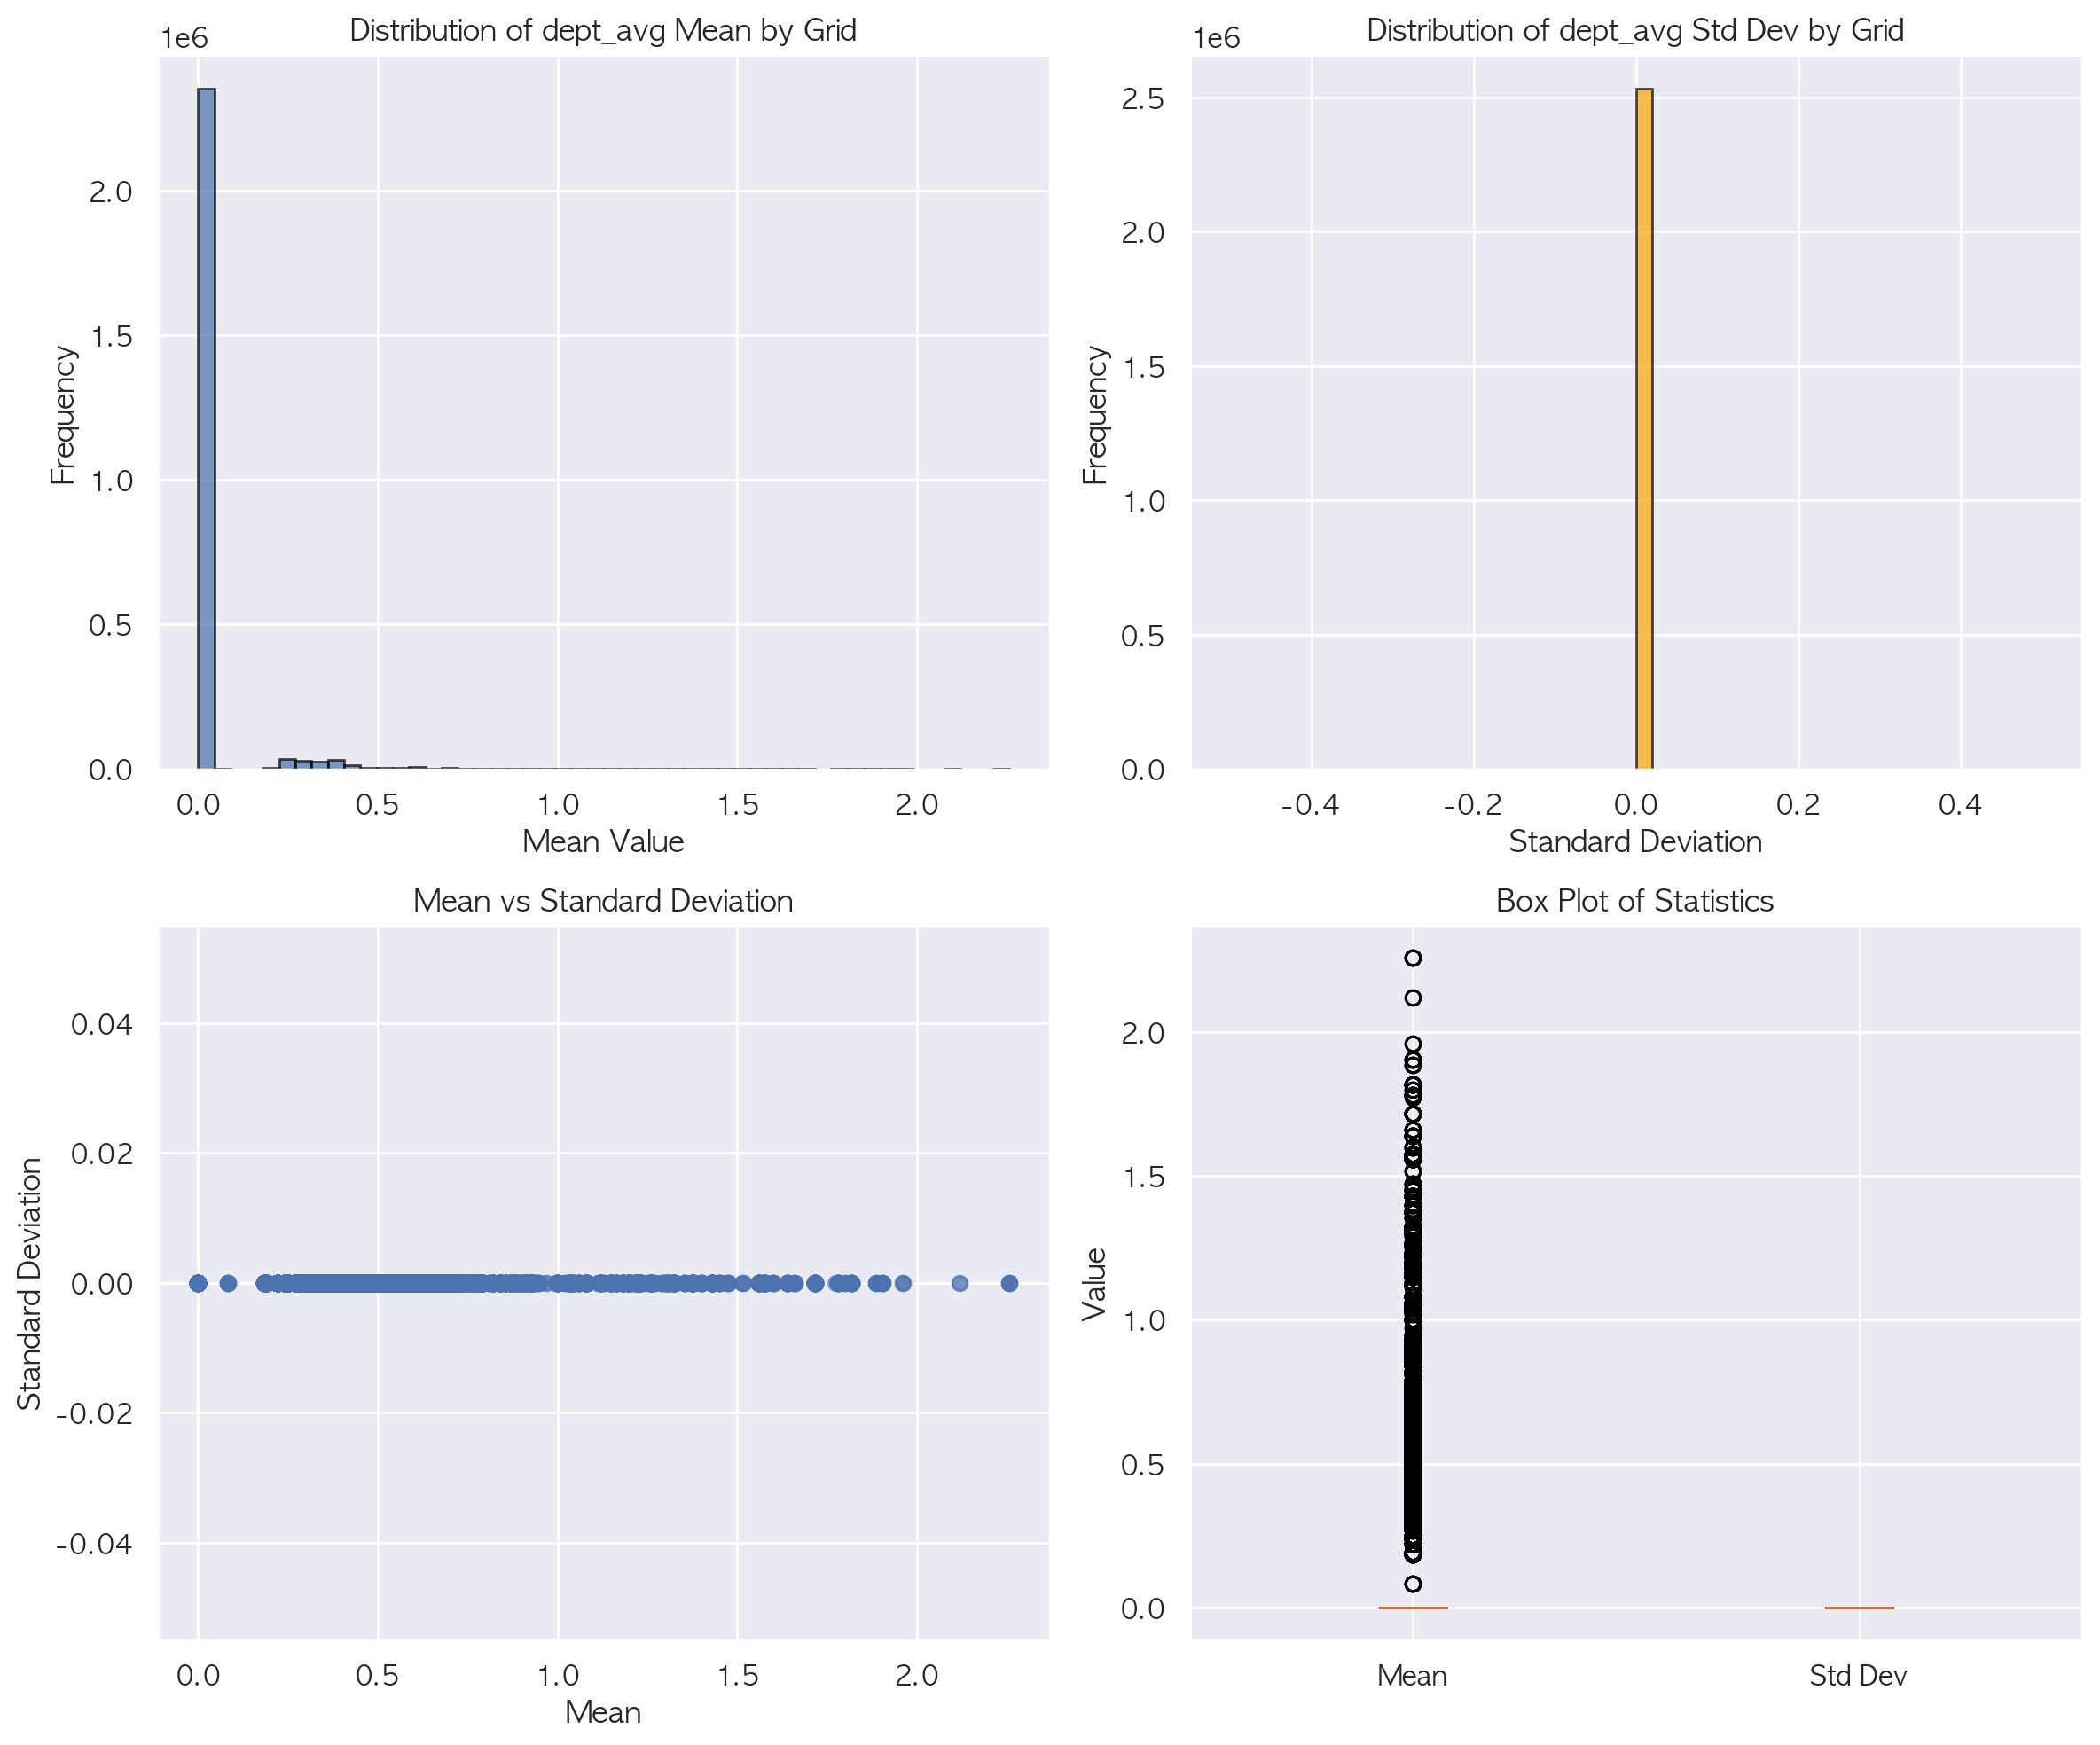


💾 통계 결과 저장됨: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/10grid/grid_flooded_area_statistics.csv

🌊 침수 그리드 분석:
- 침수된 그리드: 178,538 (7.0%)
- 침수되지 않은 그리드: 2,354,040 (93.0%)


In [24]:
# ─── Flooded_area 그리드별 통계 분석 ───

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) 데이터 로드
df = pd.read_csv('/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/10grid/SCI_flood_risk_data.csv')

# 2) 데이터 구조 확인
print("📊 데이터셋 정보:")
print(f"- 전체 행 수: {len(df):,}")
print(f"- 전체 열 수: {len(df.columns)}")
print("\n📋 컬럼 목록:")
print(df.columns.tolist())

# 3) Flooded_area 관련 컬럼 찾기
# 'Flooded_area' 또는 유사한 이름의 컬럼 찾기
flooded_cols = [col for col in df.columns if 'flood' in col.lower() or 'area' in col.lower()]
print(f"\n🔍 Flood/Area 관련 컬럼: {flooded_cols}")

# 만약 정확한 컬럼명이 없다면, dept_avg를 사용하거나 사용자에게 확인 요청
if 'Flooded_area' in df.columns:
    target_col = 'Flooded_area'
elif 'flooded_area' in df.columns:
    target_col = 'flooded_area'
else:
    print("\n⚠️ 'Flooded_area' 컬럼을 찾을 수 없습니다.")
    print("사용 가능한 컬럼 중 관련된 것을 선택해주세요:")
    # dept_avg가 침수 깊이라면 이를 사용할 수도 있음
    if 'dept_avg' in df.columns:
        print("'dept_avg' 컬럼을 사용하여 분석을 진행합니다.")
        target_col = 'dept_avg'
    else:
        # 실제 컬럼명 확인 필요
        print("데이터의 첫 5개 컬럼:", df.columns[:5].tolist())
        target_col = None

if target_col:
    # 4) 그리드 식별 컬럼 찾기
    # 일반적으로 'grid_id', 'GRID_ID', 'id', 'FID' 등의 이름 사용
    grid_cols = [col for col in df.columns if 'grid' in col.lower() or col.lower() in ['id', 'fid', 'objectid']]
    print(f"\n🔍 그리드 관련 컬럼: {grid_cols}")
    
    # 그리드 ID 컬럼 선택 (없으면 인덱스 사용)
    if grid_cols:
        grid_id_col = grid_cols[0]
        print(f"사용할 그리드 ID 컬럼: {grid_id_col}")
    else:
        # 그리드 ID가 없으면 인덱스를 그리드 ID로 사용
        df['grid_id'] = df.index
        grid_id_col = 'grid_id'
        print("그리드 ID 컬럼이 없어 인덱스를 사용합니다.")
    
    # 5) 각 그리드별 통계 계산
    print(f"\n📈 각 그리드별 {target_col} 통계 계산 중...")
    
    # 그리드별 그룹화 및 통계 계산
    grid_stats = df.groupby(grid_id_col)[target_col].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('min', 'min'),
        ('max', 'max'),
        ('count', 'count'),
        ('sum', 'sum')
    ]).reset_index()
    
    # NaN 값을 0으로 대체 (std가 NaN인 경우는 단일 값만 있는 경우)
    grid_stats['std'] = grid_stats['std'].fillna(0)
    
    # 6) 결과 출력
    print(f"\n📊 그리드별 {target_col} 통계 요약:")
    print(f"- 총 그리드 수: {len(grid_stats):,}")
    print(f"- 평균의 평균: {grid_stats['mean'].mean():.4f}")
    print(f"- 평균의 표준편차: {grid_stats['mean'].std():.4f}")
    print(f"- 표준편차의 평균: {grid_stats['std'].mean():.4f}")
    
    # 상위 10개 그리드 표시
    print(f"\n🔝 {target_col} 평균이 높은 상위 10개 그리드:")
    top_10 = grid_stats.nlargest(10, 'mean')
    print(top_10[[grid_id_col, 'mean', 'std', 'count']])
    
    # 7) 시각화
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 평균값 분포
    axes[0, 0].hist(grid_stats['mean'], bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title(f'Distribution of {target_col} Mean by Grid')
    axes[0, 0].set_xlabel('Mean Value')
    axes[0, 0].set_ylabel('Frequency')
    
    # 표준편차 분포
    axes[0, 1].hist(grid_stats['std'], bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[0, 1].set_title(f'Distribution of {target_col} Std Dev by Grid')
    axes[0, 1].set_xlabel('Standard Deviation')
    axes[0, 1].set_ylabel('Frequency')
    
    # 평균 vs 표준편차 산점도
    axes[1, 0].scatter(grid_stats['mean'], grid_stats['std'], alpha=0.5)
    axes[1, 0].set_title('Mean vs Standard Deviation')
    axes[1, 0].set_xlabel('Mean')
    axes[1, 0].set_ylabel('Standard Deviation')
    
    # 박스플롯
    axes[1, 1].boxplot([grid_stats['mean'], grid_stats['std']], 
                       labels=['Mean', 'Std Dev'])
    axes[1, 1].set_title('Box Plot of Statistics')
    axes[1, 1].set_ylabel('Value')
    
    plt.tight_layout()
    plt.show()
    
    # 8) 결과 저장
    output_path = '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/10grid'
    stats_file = f'{output_path}/grid_flooded_area_statistics.csv'
    grid_stats.to_csv(stats_file, index=False)
    print(f"\n💾 통계 결과 저장됨: {stats_file}")
    
    # 9) 추가 분석: 침수/비침수 그리드 비율
    if target_col == 'dept_avg':
        flooded_grids = (grid_stats['mean'] > 0).sum()
        total_grids = len(grid_stats)
        print(f"\n🌊 침수 그리드 분석:")
        print(f"- 침수된 그리드: {flooded_grids:,} ({flooded_grids/total_grids*100:.1f}%)")
        print(f"- 침수되지 않은 그리드: {total_grids-flooded_grids:,} ({(total_grids-flooded_grids)/total_grids*100:.1f}%)")

else:
    print("\n❌ 분석을 수행할 수 없습니다. 정확한 컬럼명을 확인해주세요.")
    print("\n사용 가능한 모든 컬럼:")
    for i, col in enumerate(df.columns):
        print(f"{i}: {col}")

📊 데이터셋 정보:
- 전체 행 수: 2,532,578
- 전체 열 수: 10

📋 컬럼 목록:
['fid', 'dept_avg', 'length_sew', 'drainscore_avg', 'permeable', 'height', 'slope_avg', 'numpoints', 'distance_avg', 'river_distance_avg']

🔍 Flood/Area 관련 컬럼: []
'dept_avg' 컬럼을 사용하여 분석을 진행합니다.

🔄 dept_avg 이진분류 변환 중...
원본 dept_avg 값 범위: 0.0000 ~ 2.2580
0인 데이터 개수: 2,354,040
0보다 큰 데이터 개수: 178,538

✅ 이진분류 결과:
- 비침수 (0): 2,354,040 개 (93.0%)
- 침수 (1): 178,538 개 (7.0%)

🔍 그리드 관련 컬럼: ['fid']
사용할 그리드 ID 컬럼: fid

📈 각 그리드별 이진분류 통계 계산 중...

📊 그리드별 이진분류 통계 요약:
- 총 그리드 수: 2,532,578
- 침수 비율 평균: 0.0705
- 침수 비율 표준편차: 0.2560

🏷️ 그리드 카테고리별 분포:
- 완전비침수: 2,354,040개 (93.0%)
- 완전침수: 178,538개 (7.0%)
- 저침수: 0개 (0.0%)
- 중침수: 0개 (0.0%)
- 고침수: 0개 (0.0%)

🔝 침수 비율이 높은 상위 10개 그리드:
     fid          flood_ratio  flooded_points  total_points grid_category
785  786                1.000               1             1          완전침수
786  787                1.000               1             1          완전침수
787  788                1.000               1             1     

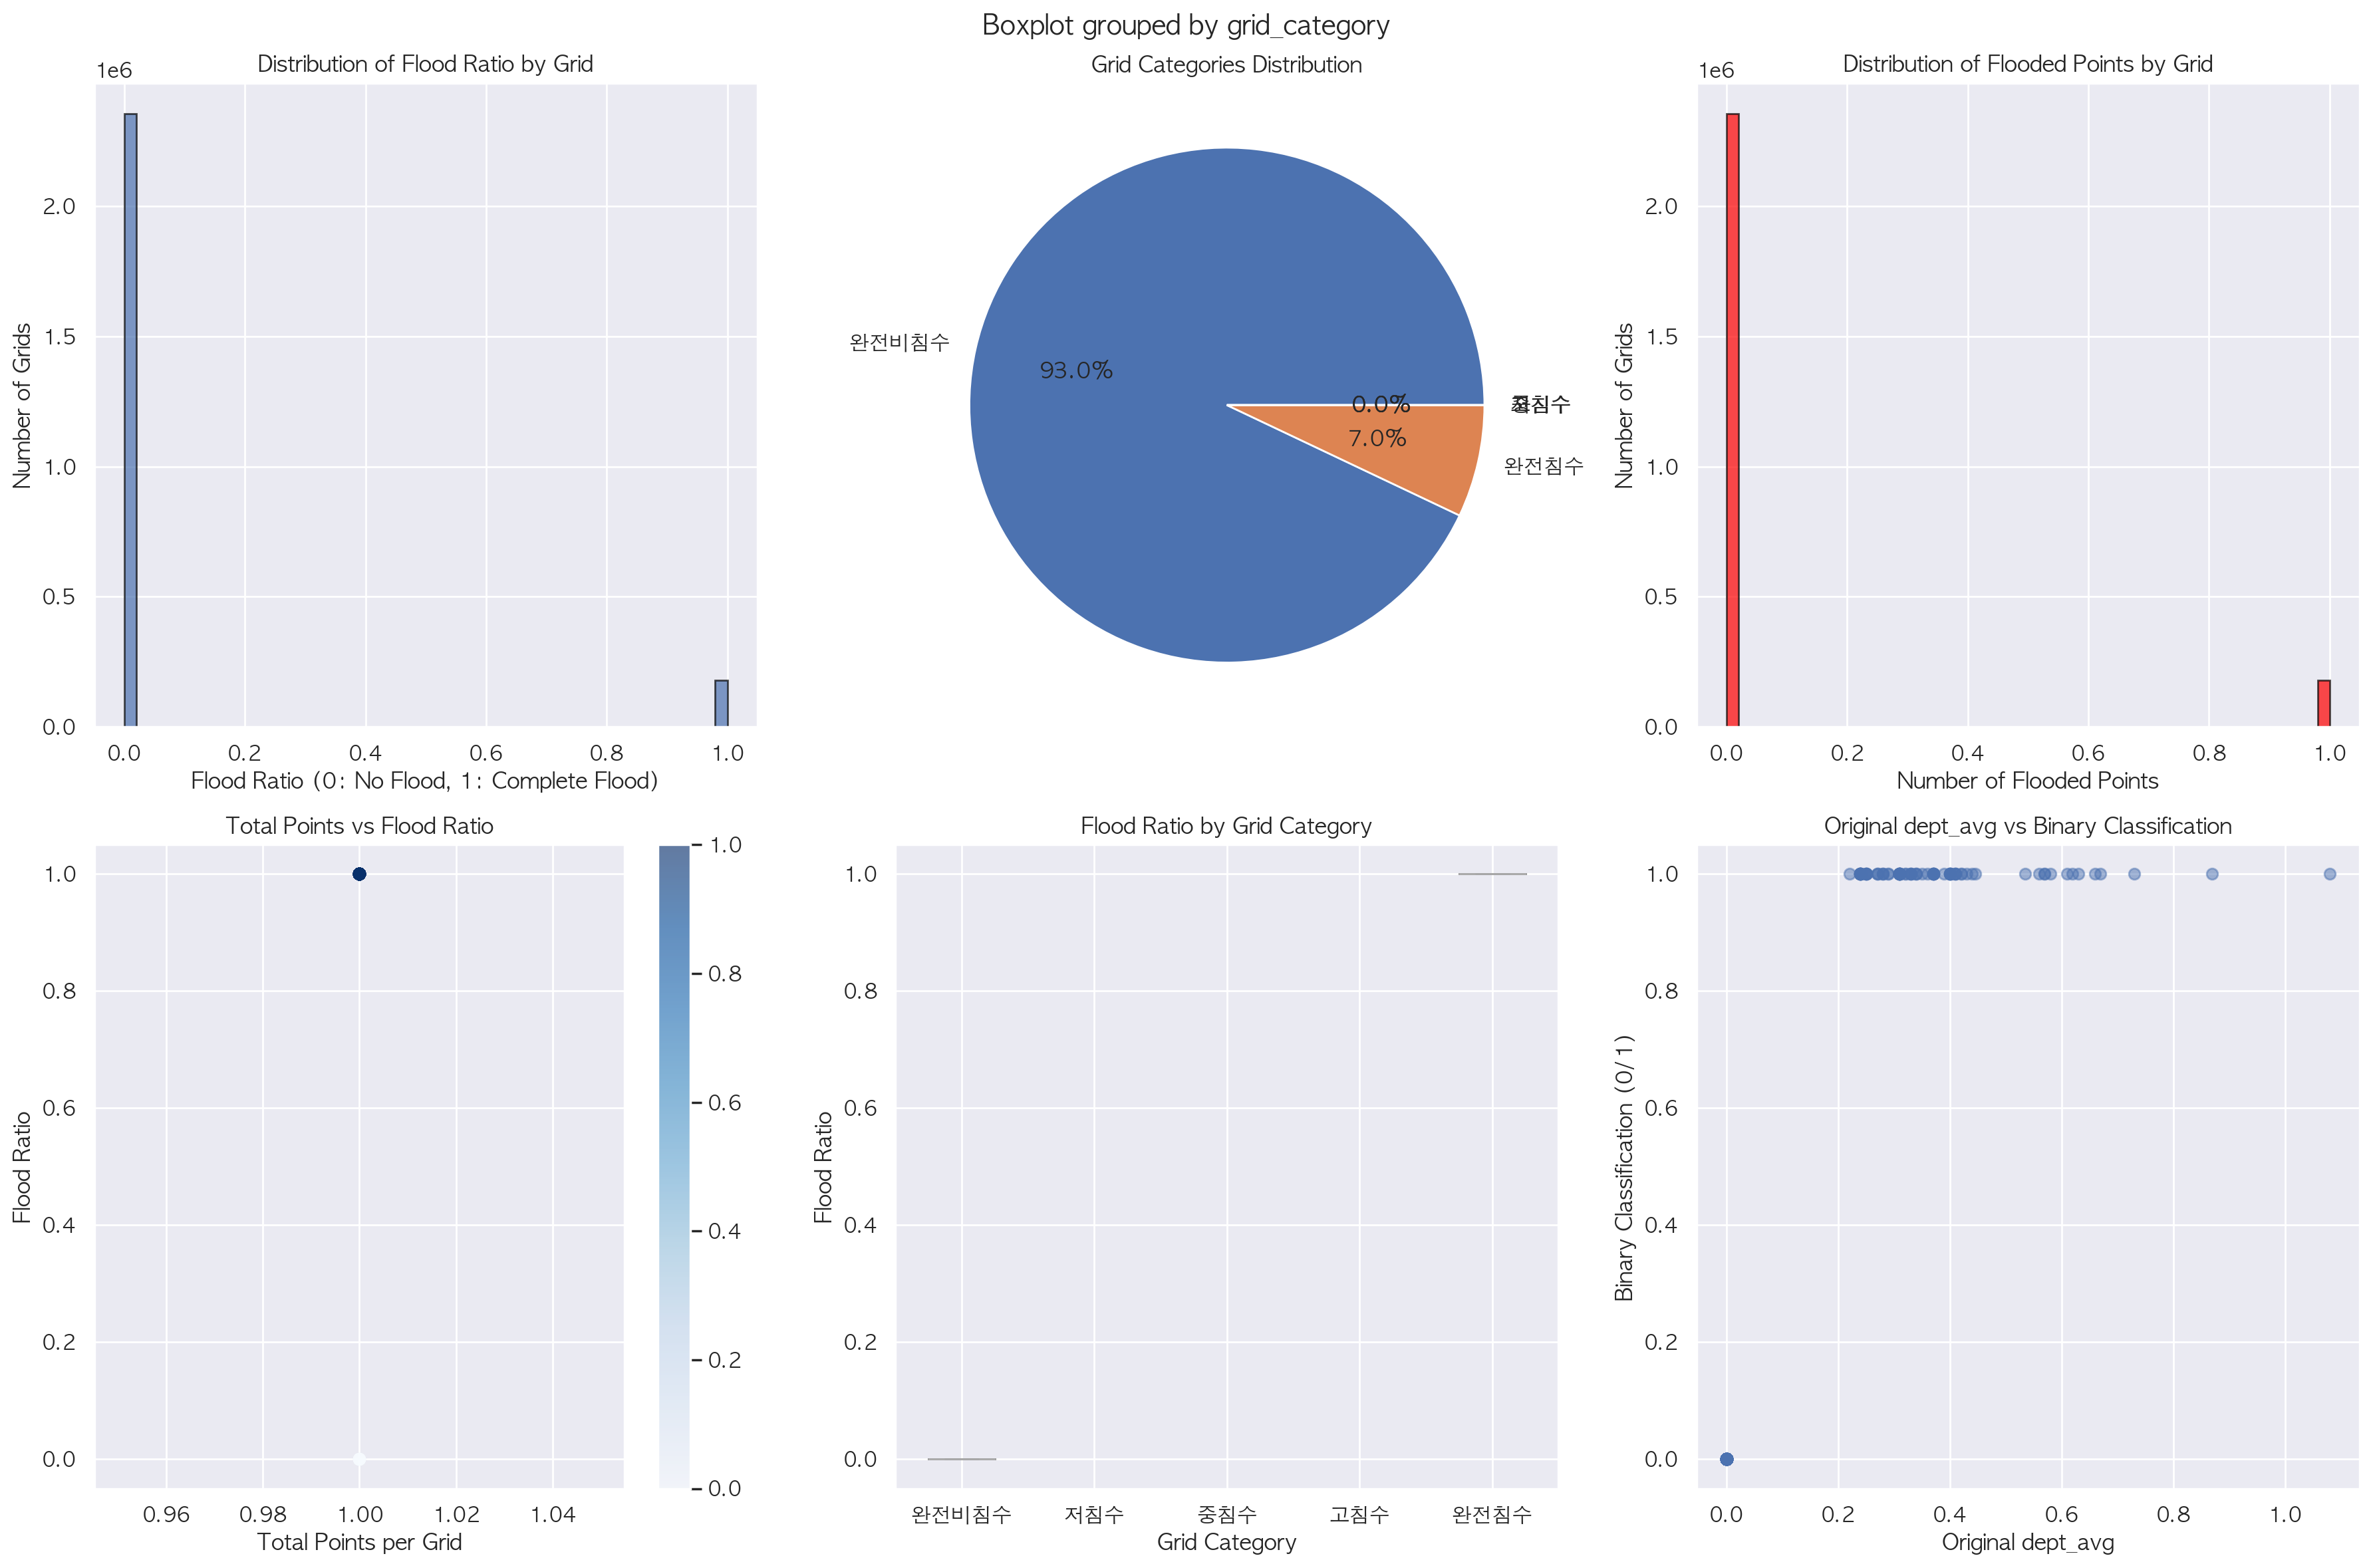


📊 상세 통계 분석:

침수 비율 구간별 그리드 분포:
- 0-10%: 2,354,040개 (93.0%)
- 10-25%: 0개 (0.0%)
- 25-50%: 0개 (0.0%)
- 50-75%: 0개 (0.0%)
- 75-90%: 0개 (0.0%)
- 90-100%: 178,538개 (7.0%)

💾 파일 저장 완료:
- 이진분류 통계: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/10grid/grid_binary_flood_statistics.csv
- 이진분류 데이터: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/10grid/flood_data_with_binary.csv

📋 최종 요약 리포트:
전체 데이터 포인트: 2,532,578
전체 그리드 수: 2,532,578
평균 침수 비율: 0.070
완전침수 그리드: 178,538개 (7.0%)
완전비침수 그리드: 2,354,040개 (93.0%)
부분침수 그리드: 0개


In [32]:
# ─── Flooded_area 이진분류 그리드별 통계 분석 ───

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) 데이터 로드
df = pd.read_csv('/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/10grid/SCI_flood_risk_data.csv')

# 2) 데이터 구조 확인
print("📊 데이터셋 정보:")
print(f"- 전체 행 수: {len(df):,}")
print(f"- 전체 열 수: {len(df.columns)}")
print("\n📋 컬럼 목록:")
print(df.columns.tolist())

# 3) Flooded_area 관련 컬럼 찾기
flooded_cols = [col for col in df.columns if 'flood' in col.lower() or 'area' in col.lower()]
print(f"\n🔍 Flood/Area 관련 컬럼: {flooded_cols}")

# 타겟 컬럼 선택
if 'Flooded_area' in df.columns:
    target_col = 'Flooded_area'
elif 'flooded_area' in df.columns:
    target_col = 'flooded_area'
elif 'dept_avg' in df.columns:
    print("'dept_avg' 컬럼을 사용하여 분석을 진행합니다.")
    target_col = 'dept_avg'
else:
    print("\n⚠️ 적절한 컬럼을 찾을 수 없습니다.")
    print("사용 가능한 컬럼:", df.columns.tolist()[:10])
    target_col = None

if target_col:
    # 4) 이진분류 변환 (0: 비침수, 1: 침수)
    print(f"\n🔄 {target_col} 이진분류 변환 중...")
    
    # 원본 값 확인
    print(f"원본 {target_col} 값 범위: {df[target_col].min():.4f} ~ {df[target_col].max():.4f}")
    print(f"0인 데이터 개수: {(df[target_col] == 0).sum():,}")
    print(f"0보다 큰 데이터 개수: {(df[target_col] > 0).sum():,}")
    
    # 이진분류 생성
    df['flooded_binary'] = (df[target_col] > 0).astype(int)
    
    print(f"\n✅ 이진분류 결과:")
    print(f"- 비침수 (0): {(df['flooded_binary'] == 0).sum():,} 개 ({(df['flooded_binary'] == 0).sum()/len(df)*100:.1f}%)")
    print(f"- 침수 (1): {(df['flooded_binary'] == 1).sum():,} 개 ({(df['flooded_binary'] == 1).sum()/len(df)*100:.1f}%)")
    
    # 5) 그리드 ID 컬럼 찾기
    grid_cols = [col for col in df.columns if 'grid' in col.lower() or col.lower() in ['id', 'fid', 'objectid']]
    print(f"\n🔍 그리드 관련 컬럼: {grid_cols}")
    
    if grid_cols:
        grid_id_col = grid_cols[0]
        print(f"사용할 그리드 ID 컬럼: {grid_id_col}")
    else:
        df['grid_id'] = df.index
        grid_id_col = 'grid_id'
        print("그리드 ID 컬럼이 없어 인덱스를 사용합니다.")
    
    # 6) 그리드별 이진분류 통계 계산
    print(f"\n📈 각 그리드별 이진분류 통계 계산 중...")
    
    grid_binary_stats = df.groupby(grid_id_col)['flooded_binary'].agg([
        ('flood_ratio', 'mean'),      # 침수 비율 (0~1)
        ('total_points', 'count'),    # 총 포인트 수
        ('flooded_points', 'sum'),    # 침수된 포인트 수
        ('non_flooded_points', lambda x: (x == 0).sum())  # 비침수 포인트 수
    ]).reset_index()
    
    # 침수 비율에 따른 그리드 분류
    grid_binary_stats['grid_category'] = pd.cut(
        grid_binary_stats['flood_ratio'], 
        bins=[-0.1, 0, 0.25, 0.5, 0.75, 1.0],
        labels=['완전비침수', '저침수', '중침수', '고침수', '완전침수']
    )
    
    # 7) 결과 출력
    print(f"\n📊 그리드별 이진분류 통계 요약:")
    print(f"- 총 그리드 수: {len(grid_binary_stats):,}")
    print(f"- 침수 비율 평균: {grid_binary_stats['flood_ratio'].mean():.4f}")
    print(f"- 침수 비율 표준편차: {grid_binary_stats['flood_ratio'].std():.4f}")
    
    # 그리드 카테고리별 분포
    print(f"\n🏷️ 그리드 카테고리별 분포:")
    category_counts = grid_binary_stats['grid_category'].value_counts()
    for category, count in category_counts.items():
        percentage = count / len(grid_binary_stats) * 100
        print(f"- {category}: {count:,}개 ({percentage:.1f}%)")
    
    # 침수 비율이 높은 상위 10개 그리드
    print(f"\n🔝 침수 비율이 높은 상위 10개 그리드:")
    top_10_flooded = grid_binary_stats.nlargest(10, 'flood_ratio')
    print(top_10_flooded[[grid_id_col, 'flood_ratio', 'flooded_points', 'total_points', 'grid_category']])
    
    # 완전히 침수된 그리드와 완전히 비침수인 그리드
    completely_flooded = (grid_binary_stats['flood_ratio'] == 1.0).sum()
    completely_non_flooded = (grid_binary_stats['flood_ratio'] == 0.0).sum()
    
    print(f"\n🌊 극단적 침수 상황:")
    print(f"- 완전침수 그리드: {completely_flooded:,}개")
    print(f"- 완전비침수 그리드: {completely_non_flooded:,}개")
    print(f"- 부분침수 그리드: {len(grid_binary_stats) - completely_flooded - completely_non_flooded:,}개")
    
    # 8) 시각화
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 침수 비율 분포
    axes[0, 0].hist(grid_binary_stats['flood_ratio'], bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Distribution of Flood Ratio by Grid')
    axes[0, 0].set_xlabel('Flood Ratio (0: No Flood, 1: Complete Flood)')
    axes[0, 0].set_ylabel('Number of Grids')
    
    # 그리드 카테고리 파이차트
    axes[0, 1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%')
    axes[0, 1].set_title('Grid Categories Distribution')
    
    # 침수 포인트 수 분포
    axes[0, 2].hist(grid_binary_stats['flooded_points'], bins=50, edgecolor='black', alpha=0.7, color='red')
    axes[0, 2].set_title('Distribution of Flooded Points by Grid')
    axes[0, 2].set_xlabel('Number of Flooded Points')
    axes[0, 2].set_ylabel('Number of Grids')
    
    # 총 포인트 수 vs 침수 비율
    scatter = axes[1, 0].scatter(grid_binary_stats['total_points'], 
                                grid_binary_stats['flood_ratio'], 
                                alpha=0.6, c=grid_binary_stats['flood_ratio'], 
                                cmap='Blues')
    axes[1, 0].set_title('Total Points vs Flood Ratio')
    axes[1, 0].set_xlabel('Total Points per Grid')
    axes[1, 0].set_ylabel('Flood Ratio')
    plt.colorbar(scatter, ax=axes[1, 0])
    
    # 침수 비율 박스플롯 (카테고리별)
    grid_binary_stats.boxplot(column='flood_ratio', by='grid_category', ax=axes[1, 1])
    axes[1, 1].set_title('Flood Ratio by Grid Category')
    axes[1, 1].set_xlabel('Grid Category')
    axes[1, 1].set_ylabel('Flood Ratio')
    
    # 원본 값 vs 이진분류 값 비교
    sample_data = df.sample(min(1000, len(df)))  # 샘플링으로 시각화
    axes[1, 2].scatter(sample_data[target_col], sample_data['flooded_binary'], alpha=0.5)
    axes[1, 2].set_title(f'Original {target_col} vs Binary Classification')
    axes[1, 2].set_xlabel(f'Original {target_col}')
    axes[1, 2].set_ylabel('Binary Classification (0/1)')
    
    plt.tight_layout()
    plt.show()
    
    # 9) 추가 통계 분석
    print(f"\n📊 상세 통계 분석:")
    
    # 침수 비율별 구간 분석
    ratio_bins = [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
    ratio_labels = ['0-10%', '10-25%', '25-50%', '50-75%', '75-90%', '90-100%']
    grid_binary_stats['ratio_bin'] = pd.cut(grid_binary_stats['flood_ratio'], 
                                           bins=ratio_bins, labels=ratio_labels, include_lowest=True)
    
    print("\n침수 비율 구간별 그리드 분포:")
    ratio_distribution = grid_binary_stats['ratio_bin'].value_counts().sort_index()
    for ratio_range, count in ratio_distribution.items():
        percentage = count / len(grid_binary_stats) * 100
        print(f"- {ratio_range}: {count:,}개 ({percentage:.1f}%)")
    
    # 10) 결과 저장
    output_path = '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/10grid'
    
    # 그리드별 이진분류 통계 저장
    binary_stats_file = f'{output_path}/grid_binary_flood_statistics.csv'
    grid_binary_stats.to_csv(binary_stats_file, index=False)
    
    # 원본 데이터에 이진분류 컬럼 추가하여 저장
    binary_data_file = f'{output_path}/flood_data_with_binary.csv'
    df.to_csv(binary_data_file, index=False)
    
    print(f"\n💾 파일 저장 완료:")
    print(f"- 이진분류 통계: {binary_stats_file}")
    print(f"- 이진분류 데이터: {binary_data_file}")
    
    # 11) 요약 리포트
    print(f"\n📋 최종 요약 리포트:")
    print(f"{'='*50}")
    print(f"전체 데이터 포인트: {len(df):,}")
    print(f"전체 그리드 수: {len(grid_binary_stats):,}")
    print(f"평균 침수 비율: {grid_binary_stats['flood_ratio'].mean():.3f}")
    print(f"완전침수 그리드: {completely_flooded:,}개 ({completely_flooded/len(grid_binary_stats)*100:.1f}%)")
    print(f"완전비침수 그리드: {completely_non_flooded:,}개 ({completely_non_flooded/len(grid_binary_stats)*100:.1f}%)")
    print(f"부분침수 그리드: {len(grid_binary_stats) - completely_flooded - completely_non_flooded:,}개")
    print(f"{'='*50}")

else:
    print("\n❌ 분석을 수행할 수 없습니다. 정확한 컬럼명을 확인해주세요.")
    print("\n사용 가능한 모든 컬럼:")
    for i, col in enumerate(df.columns):
        print(f"{i}: {col}")

## 30grid

In [30]:
import pandas as pd
import numpy as np

# 데이터 로드
df = pd.read_csv('/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/30grid/SCI_30grid_flood_risk_data.csv')

# Flooded_area 컬럼 찾기
if 'Flooded_area' in df.columns:
    target_col = 'Flooded_area'
elif 'flooded_area' in df.columns:
    target_col = 'flooded_area'
elif 'dept_avg' in df.columns:
    target_col = 'dept_avg'
else:
    print("Flooded_area 관련 컬럼을 찾을 수 없습니다.")
    print("사용 가능한 컬럼:", df.columns.tolist())
    target_col = None

if target_col:
    print(f"📊 {target_col} 기본 통계:")
    print(f"총 개수: {len(df):,}")
    print(f"평균값: {df[target_col].mean():.6f}")
    print(f"표준편차: {df[target_col].std():.6f}")
    print(f"최솟값: {df[target_col].min():.6f}")
    print(f"최댓값: {df[target_col].max():.6f}")
    
    # 이진분류 후 통계 (0: 비침수, 1: 침수)
    binary_flood = (df[target_col] > 0).astype(int)
    print(f"\n📊 이진분류 후 통계:")
    print(f"평균값 (침수비율): {binary_flood.mean():.6f}")
    print(f"표준편차: {binary_flood.std():.6f}")
    print(f"침수 개수: {binary_flood.sum():,}")
    print(f"비침수 개수: {(binary_flood == 0).sum():,}")

📊 dept_avg 기본 통계:
총 개수: 276,658
평균값: 0.032973
표준편차: 0.119516
최솟값: 0.000000
최댓값: 2.258000

📊 이진분류 후 통계:
평균값 (침수비율): 0.083544
표준편차: 0.276703
침수 개수: 23,113
비침수 개수: 253,545


📊 데이터셋 정보:
- 전체 행 수: 276,658
- 전체 열 수: 10

📋 컬럼 목록:
['fid', 'dept_avg', 'length_sew', 'drainscore_avg', 'permeable', 'height', 'slope_avg', 'numpoints', 'distance_avg', 'river_distance_avg']

🔍 Flood/Area 관련 컬럼: []

⚠️ 'Flooded_area' 컬럼을 찾을 수 없습니다.
사용 가능한 컬럼 중 관련된 것을 선택해주세요:
'dept_avg' 컬럼을 사용하여 분석을 진행합니다.

🔍 그리드 관련 컬럼: ['fid']
사용할 그리드 ID 컬럼: fid

📈 각 그리드별 dept_avg 통계 계산 중...

📊 그리드별 dept_avg 통계 요약:
- 총 그리드 수: 276,658
- 평균의 평균: 0.0330
- 평균의 표준편차: 0.1195
- 표준편차의 평균: 0.0000

🔝 dept_avg 평균이 높은 상위 10개 그리드:
           fid                 mean                  std  count
223310  223311                2.258                0.000      1
223311  223312                1.887                0.000      1
20080    20081                1.817                0.000      1
20081    20082                1.817                0.000      1
20161    20162                1.817                0.000      1
20162    20163                1.817                0.000      1
20250    20251                1.817          

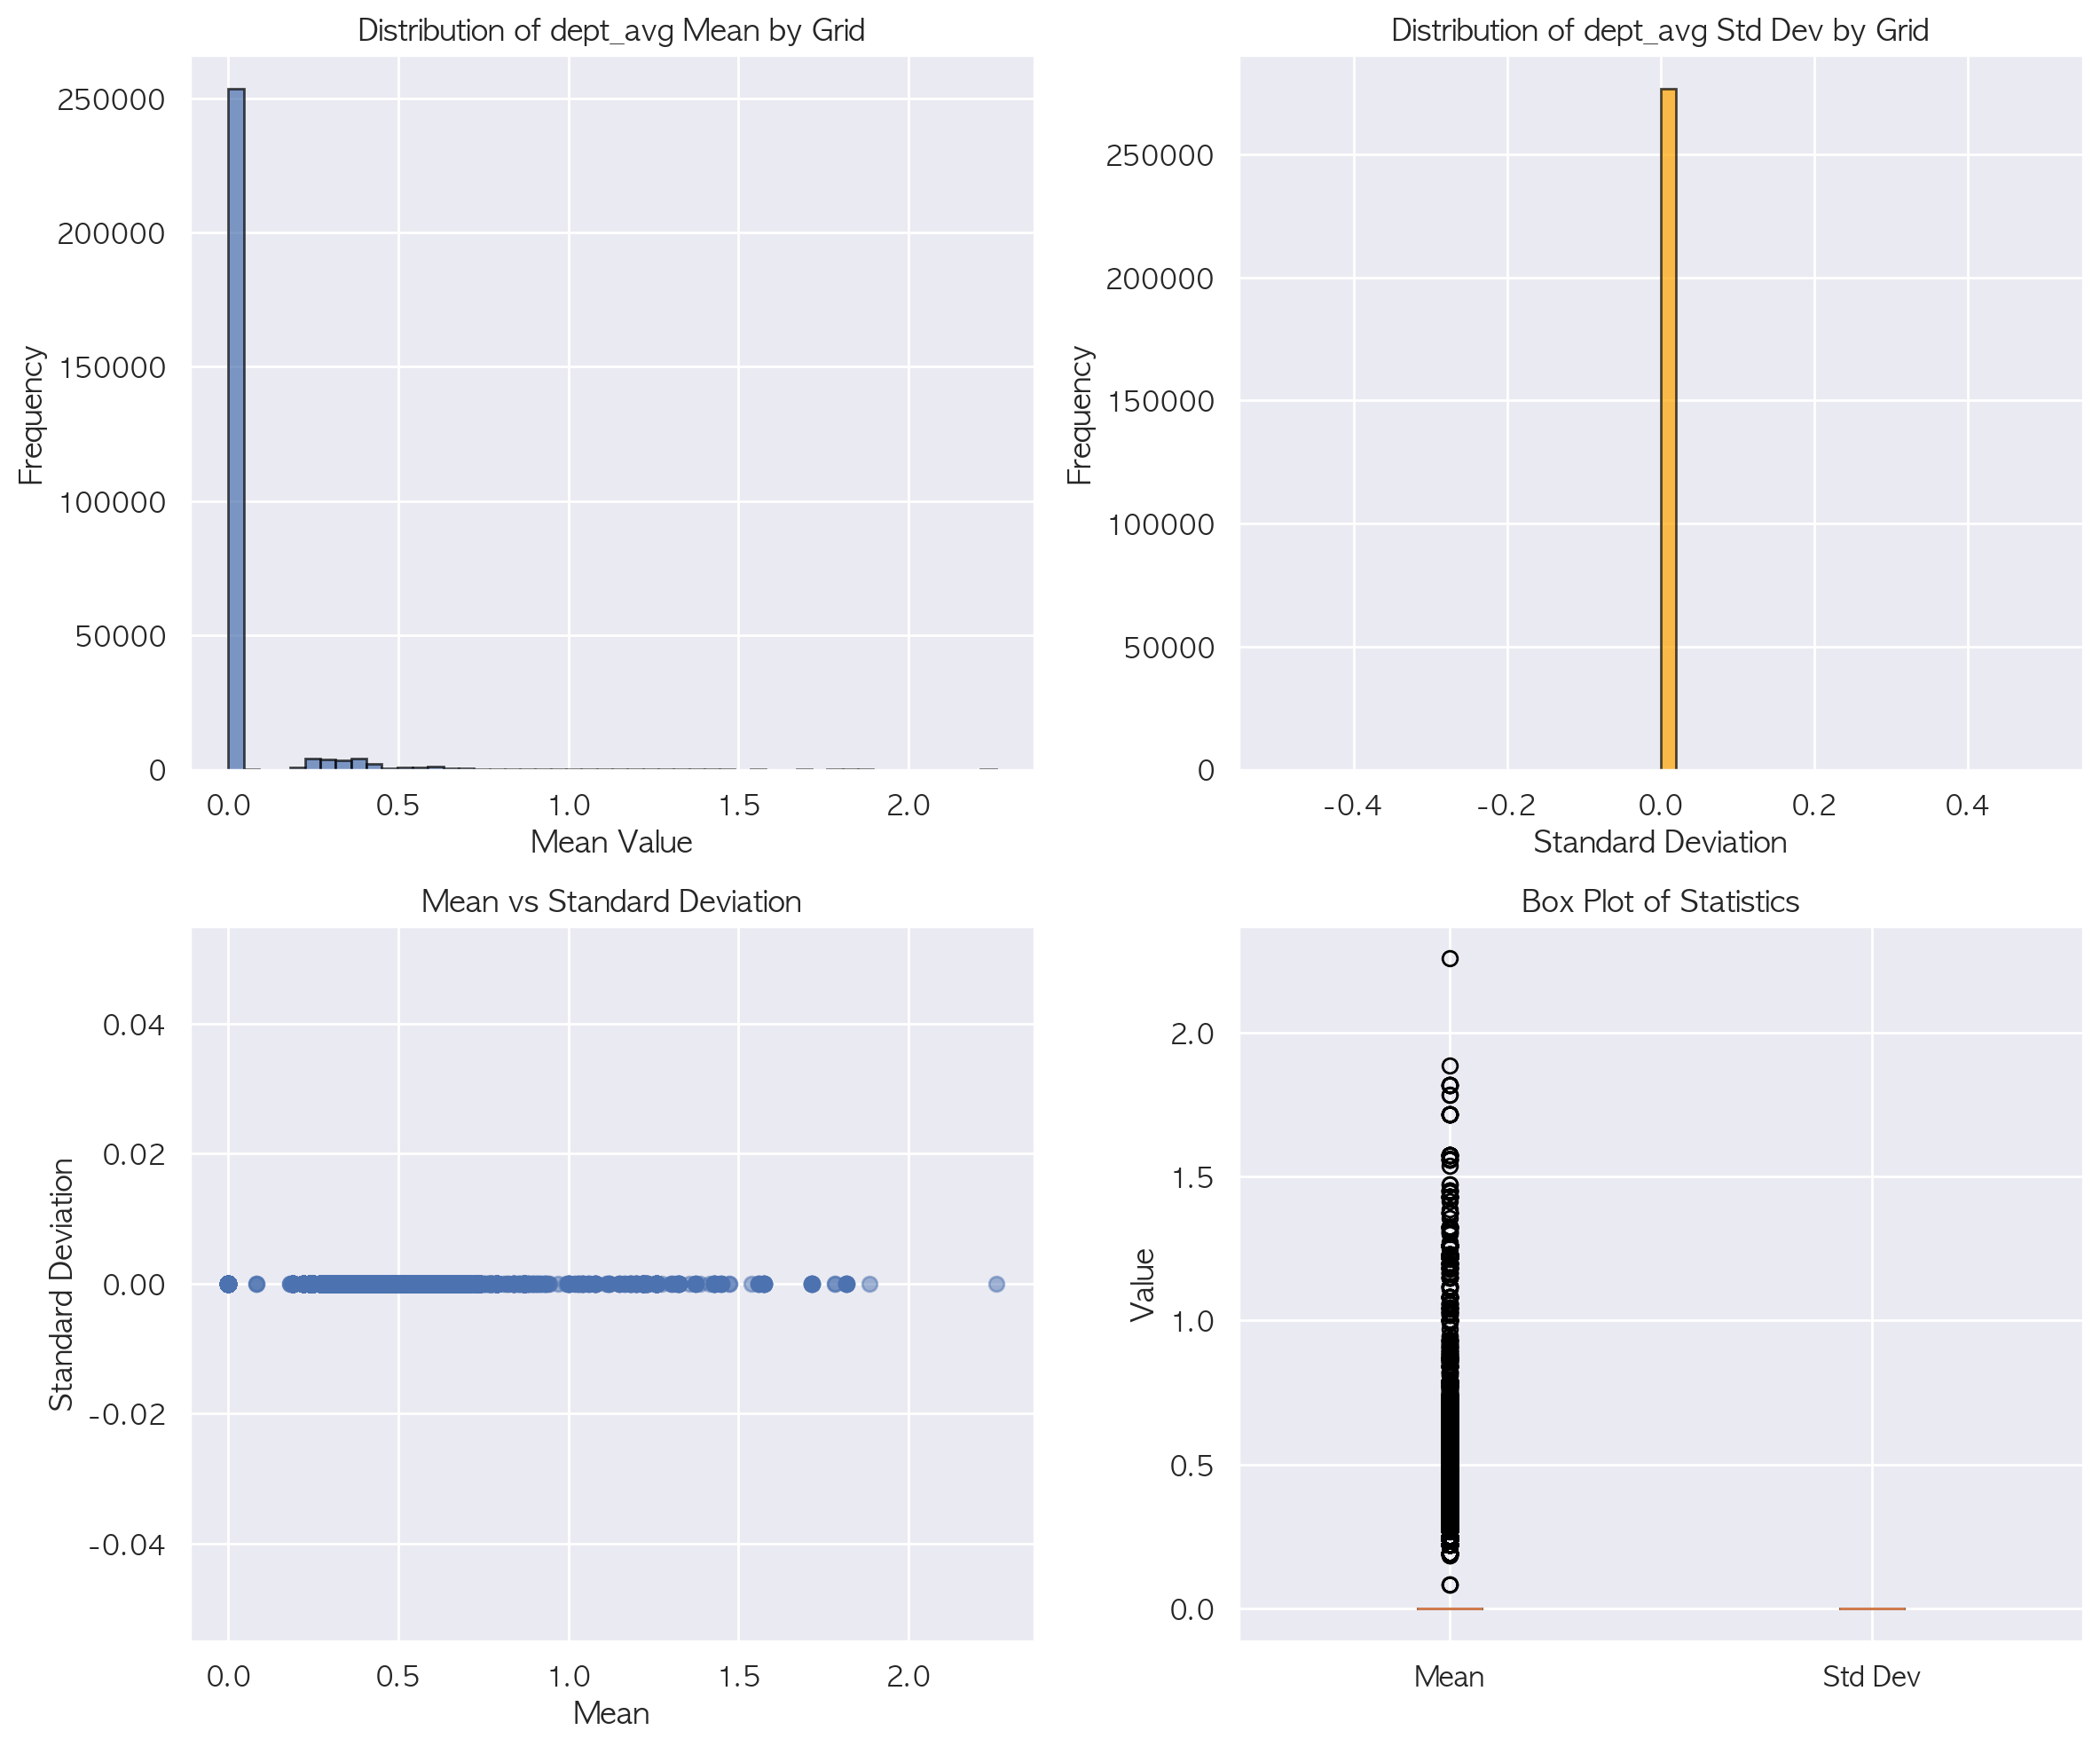


💾 통계 결과 저장됨: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/30grid/grid_flooded_area_statistics.csv

🌊 침수 그리드 분석:
- 침수된 그리드: 23,113 (8.4%)
- 침수되지 않은 그리드: 253,545 (91.6%)


In [25]:
# ─── Flooded_area 그리드별 통계 분석 ───

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) 데이터 로드
df = pd.read_csv('/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/30grid/SCI_30grid_flood_risk_data.csv')

# 2) 데이터 구조 확인
print("📊 데이터셋 정보:")
print(f"- 전체 행 수: {len(df):,}")
print(f"- 전체 열 수: {len(df.columns)}")
print("\n📋 컬럼 목록:")
print(df.columns.tolist())

# 3) Flooded_area 관련 컬럼 찾기
# 'Flooded_area' 또는 유사한 이름의 컬럼 찾기
flooded_cols = [col for col in df.columns if 'flood' in col.lower() or 'area' in col.lower()]
print(f"\n🔍 Flood/Area 관련 컬럼: {flooded_cols}")

# 만약 정확한 컬럼명이 없다면, dept_avg를 사용하거나 사용자에게 확인 요청
if 'Flooded_area' in df.columns:
    target_col = 'Flooded_area'
elif 'flooded_area' in df.columns:
    target_col = 'flooded_area'
else:
    print("\n⚠️ 'Flooded_area' 컬럼을 찾을 수 없습니다.")
    print("사용 가능한 컬럼 중 관련된 것을 선택해주세요:")
    # dept_avg가 침수 깊이라면 이를 사용할 수도 있음
    if 'dept_avg' in df.columns:
        print("'dept_avg' 컬럼을 사용하여 분석을 진행합니다.")
        target_col = 'dept_avg'
    else:
        # 실제 컬럼명 확인 필요
        print("데이터의 첫 5개 컬럼:", df.columns[:5].tolist())
        target_col = None

if target_col:
    # 4) 그리드 식별 컬럼 찾기
    # 일반적으로 'grid_id', 'GRID_ID', 'id', 'FID' 등의 이름 사용
    grid_cols = [col for col in df.columns if 'grid' in col.lower() or col.lower() in ['id', 'fid', 'objectid']]
    print(f"\n🔍 그리드 관련 컬럼: {grid_cols}")
    
    # 그리드 ID 컬럼 선택 (없으면 인덱스 사용)
    if grid_cols:
        grid_id_col = grid_cols[0]
        print(f"사용할 그리드 ID 컬럼: {grid_id_col}")
    else:
        # 그리드 ID가 없으면 인덱스를 그리드 ID로 사용
        df['grid_id'] = df.index
        grid_id_col = 'grid_id'
        print("그리드 ID 컬럼이 없어 인덱스를 사용합니다.")
    
    # 5) 각 그리드별 통계 계산
    print(f"\n📈 각 그리드별 {target_col} 통계 계산 중...")
    
    # 그리드별 그룹화 및 통계 계산
    grid_stats = df.groupby(grid_id_col)[target_col].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('min', 'min'),
        ('max', 'max'),
        ('count', 'count'),
        ('sum', 'sum')
    ]).reset_index()
    
    # NaN 값을 0으로 대체 (std가 NaN인 경우는 단일 값만 있는 경우)
    grid_stats['std'] = grid_stats['std'].fillna(0)
    
    # 6) 결과 출력
    print(f"\n📊 그리드별 {target_col} 통계 요약:")
    print(f"- 총 그리드 수: {len(grid_stats):,}")
    print(f"- 평균의 평균: {grid_stats['mean'].mean():.4f}")
    print(f"- 평균의 표준편차: {grid_stats['mean'].std():.4f}")
    print(f"- 표준편차의 평균: {grid_stats['std'].mean():.4f}")
    
    # 상위 10개 그리드 표시
    print(f"\n🔝 {target_col} 평균이 높은 상위 10개 그리드:")
    top_10 = grid_stats.nlargest(10, 'mean')
    print(top_10[[grid_id_col, 'mean', 'std', 'count']])
    
    # 7) 시각화
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 평균값 분포
    axes[0, 0].hist(grid_stats['mean'], bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title(f'Distribution of {target_col} Mean by Grid')
    axes[0, 0].set_xlabel('Mean Value')
    axes[0, 0].set_ylabel('Frequency')
    
    # 표준편차 분포
    axes[0, 1].hist(grid_stats['std'], bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[0, 1].set_title(f'Distribution of {target_col} Std Dev by Grid')
    axes[0, 1].set_xlabel('Standard Deviation')
    axes[0, 1].set_ylabel('Frequency')
    
    # 평균 vs 표준편차 산점도
    axes[1, 0].scatter(grid_stats['mean'], grid_stats['std'], alpha=0.5)
    axes[1, 0].set_title('Mean vs Standard Deviation')
    axes[1, 0].set_xlabel('Mean')
    axes[1, 0].set_ylabel('Standard Deviation')
    
    # 박스플롯
    axes[1, 1].boxplot([grid_stats['mean'], grid_stats['std']], 
                       labels=['Mean', 'Std Dev'])
    axes[1, 1].set_title('Box Plot of Statistics')
    axes[1, 1].set_ylabel('Value')
    
    plt.tight_layout()
    plt.show()
    
    # 8) 결과 저장
    output_path = '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/30grid'
    stats_file = f'{output_path}/grid_flooded_area_statistics.csv'
    grid_stats.to_csv(stats_file, index=False)
    print(f"\n💾 통계 결과 저장됨: {stats_file}")
    
    # 9) 추가 분석: 침수/비침수 그리드 비율
    if target_col == 'dept_avg':
        flooded_grids = (grid_stats['mean'] > 0).sum()
        total_grids = len(grid_stats)
        print(f"\n🌊 침수 그리드 분석:")
        print(f"- 침수된 그리드: {flooded_grids:,} ({flooded_grids/total_grids*100:.1f}%)")
        print(f"- 침수되지 않은 그리드: {total_grids-flooded_grids:,} ({(total_grids-flooded_grids)/total_grids*100:.1f}%)")

else:
    print("\n❌ 분석을 수행할 수 없습니다. 정확한 컬럼명을 확인해주세요.")
    print("\n사용 가능한 모든 컬럼:")
    for i, col in enumerate(df.columns):
        print(f"{i}: {col}")

## 100grid

In [31]:
import pandas as pd
import numpy as np

# 데이터 로드
df = pd.read_csv('/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/100grid/SCI_100grid_flood_risk_data.csv')

# Flooded_area 컬럼 찾기
if 'Flooded_area' in df.columns:
    target_col = 'Flooded_area'
elif 'flooded_area' in df.columns:
    target_col = 'flooded_area'
elif 'dept_avg' in df.columns:
    target_col = 'dept_avg'
else:
    print("Flooded_area 관련 컬럼을 찾을 수 없습니다.")
    print("사용 가능한 컬럼:", df.columns.tolist())
    target_col = None

if target_col:
    print(f"📊 {target_col} 기본 통계:")
    print(f"총 개수: {len(df):,}")
    print(f"평균값: {df[target_col].mean():.6f}")
    print(f"표준편차: {df[target_col].std():.6f}")
    print(f"최솟값: {df[target_col].min():.6f}")
    print(f"최댓값: {df[target_col].max():.6f}")
    
    # 이진분류 후 통계 (0: 비침수, 1: 침수)
    binary_flood = (df[target_col] > 0).astype(int)
    print(f"\n📊 이진분류 후 통계:")
    print(f"평균값 (침수비율): {binary_flood.mean():.6f}")
    print(f"표준편차: {binary_flood.std():.6f}")
    print(f"침수 개수: {binary_flood.sum():,}")
    print(f"비침수 개수: {(binary_flood == 0).sum():,}")

📊 dept_avg 기본 통계:
총 개수: 23,564
평균값: 0.049184
표준편차: 0.144446
최솟값: 0.000000
최댓값: 2.258000

📊 이진분류 후 통계:
평균값 (침수비율): 0.121881
표준편차: 0.327155
침수 개수: 2,872
비침수 개수: 20,692


📊 데이터셋 정보:
- 전체 행 수: 23,564
- 전체 열 수: 10

📋 컬럼 목록:
['fid', 'dept_avg', 'length_sew', 'drainscore_avg', 'permeable', 'height', 'slope_avg', 'numpoints', 'distance_avg', 'river_distance_avg']

🔍 Flood/Area 관련 컬럼: []

⚠️ 'Flooded_area' 컬럼을 찾을 수 없습니다.
사용 가능한 컬럼 중 관련된 것을 선택해주세요:
'dept_avg' 컬럼을 사용하여 분석을 진행합니다.

🔍 그리드 관련 컬럼: ['fid']
사용할 그리드 ID 컬럼: fid

📈 각 그리드별 dept_avg 통계 계산 중...

📊 그리드별 dept_avg 통계 요약:
- 총 그리드 수: 23,564
- 평균의 평균: 0.0492
- 평균의 표준편차: 0.1444
- 표준편차의 평균: 0.0000

🔝 dept_avg 평균이 높은 상위 10개 그리드:
         fid                 mean                  std  count
18966  18967                2.258                0.000      1
19069  19070                2.258                0.000      1
1527    1528                1.817                0.000      1
1526    1527                1.783                0.000      1
8483    8484                1.716                0.000      1
1547    1548                1.562                0.000      1
1546    1547                1.538                0.000      1

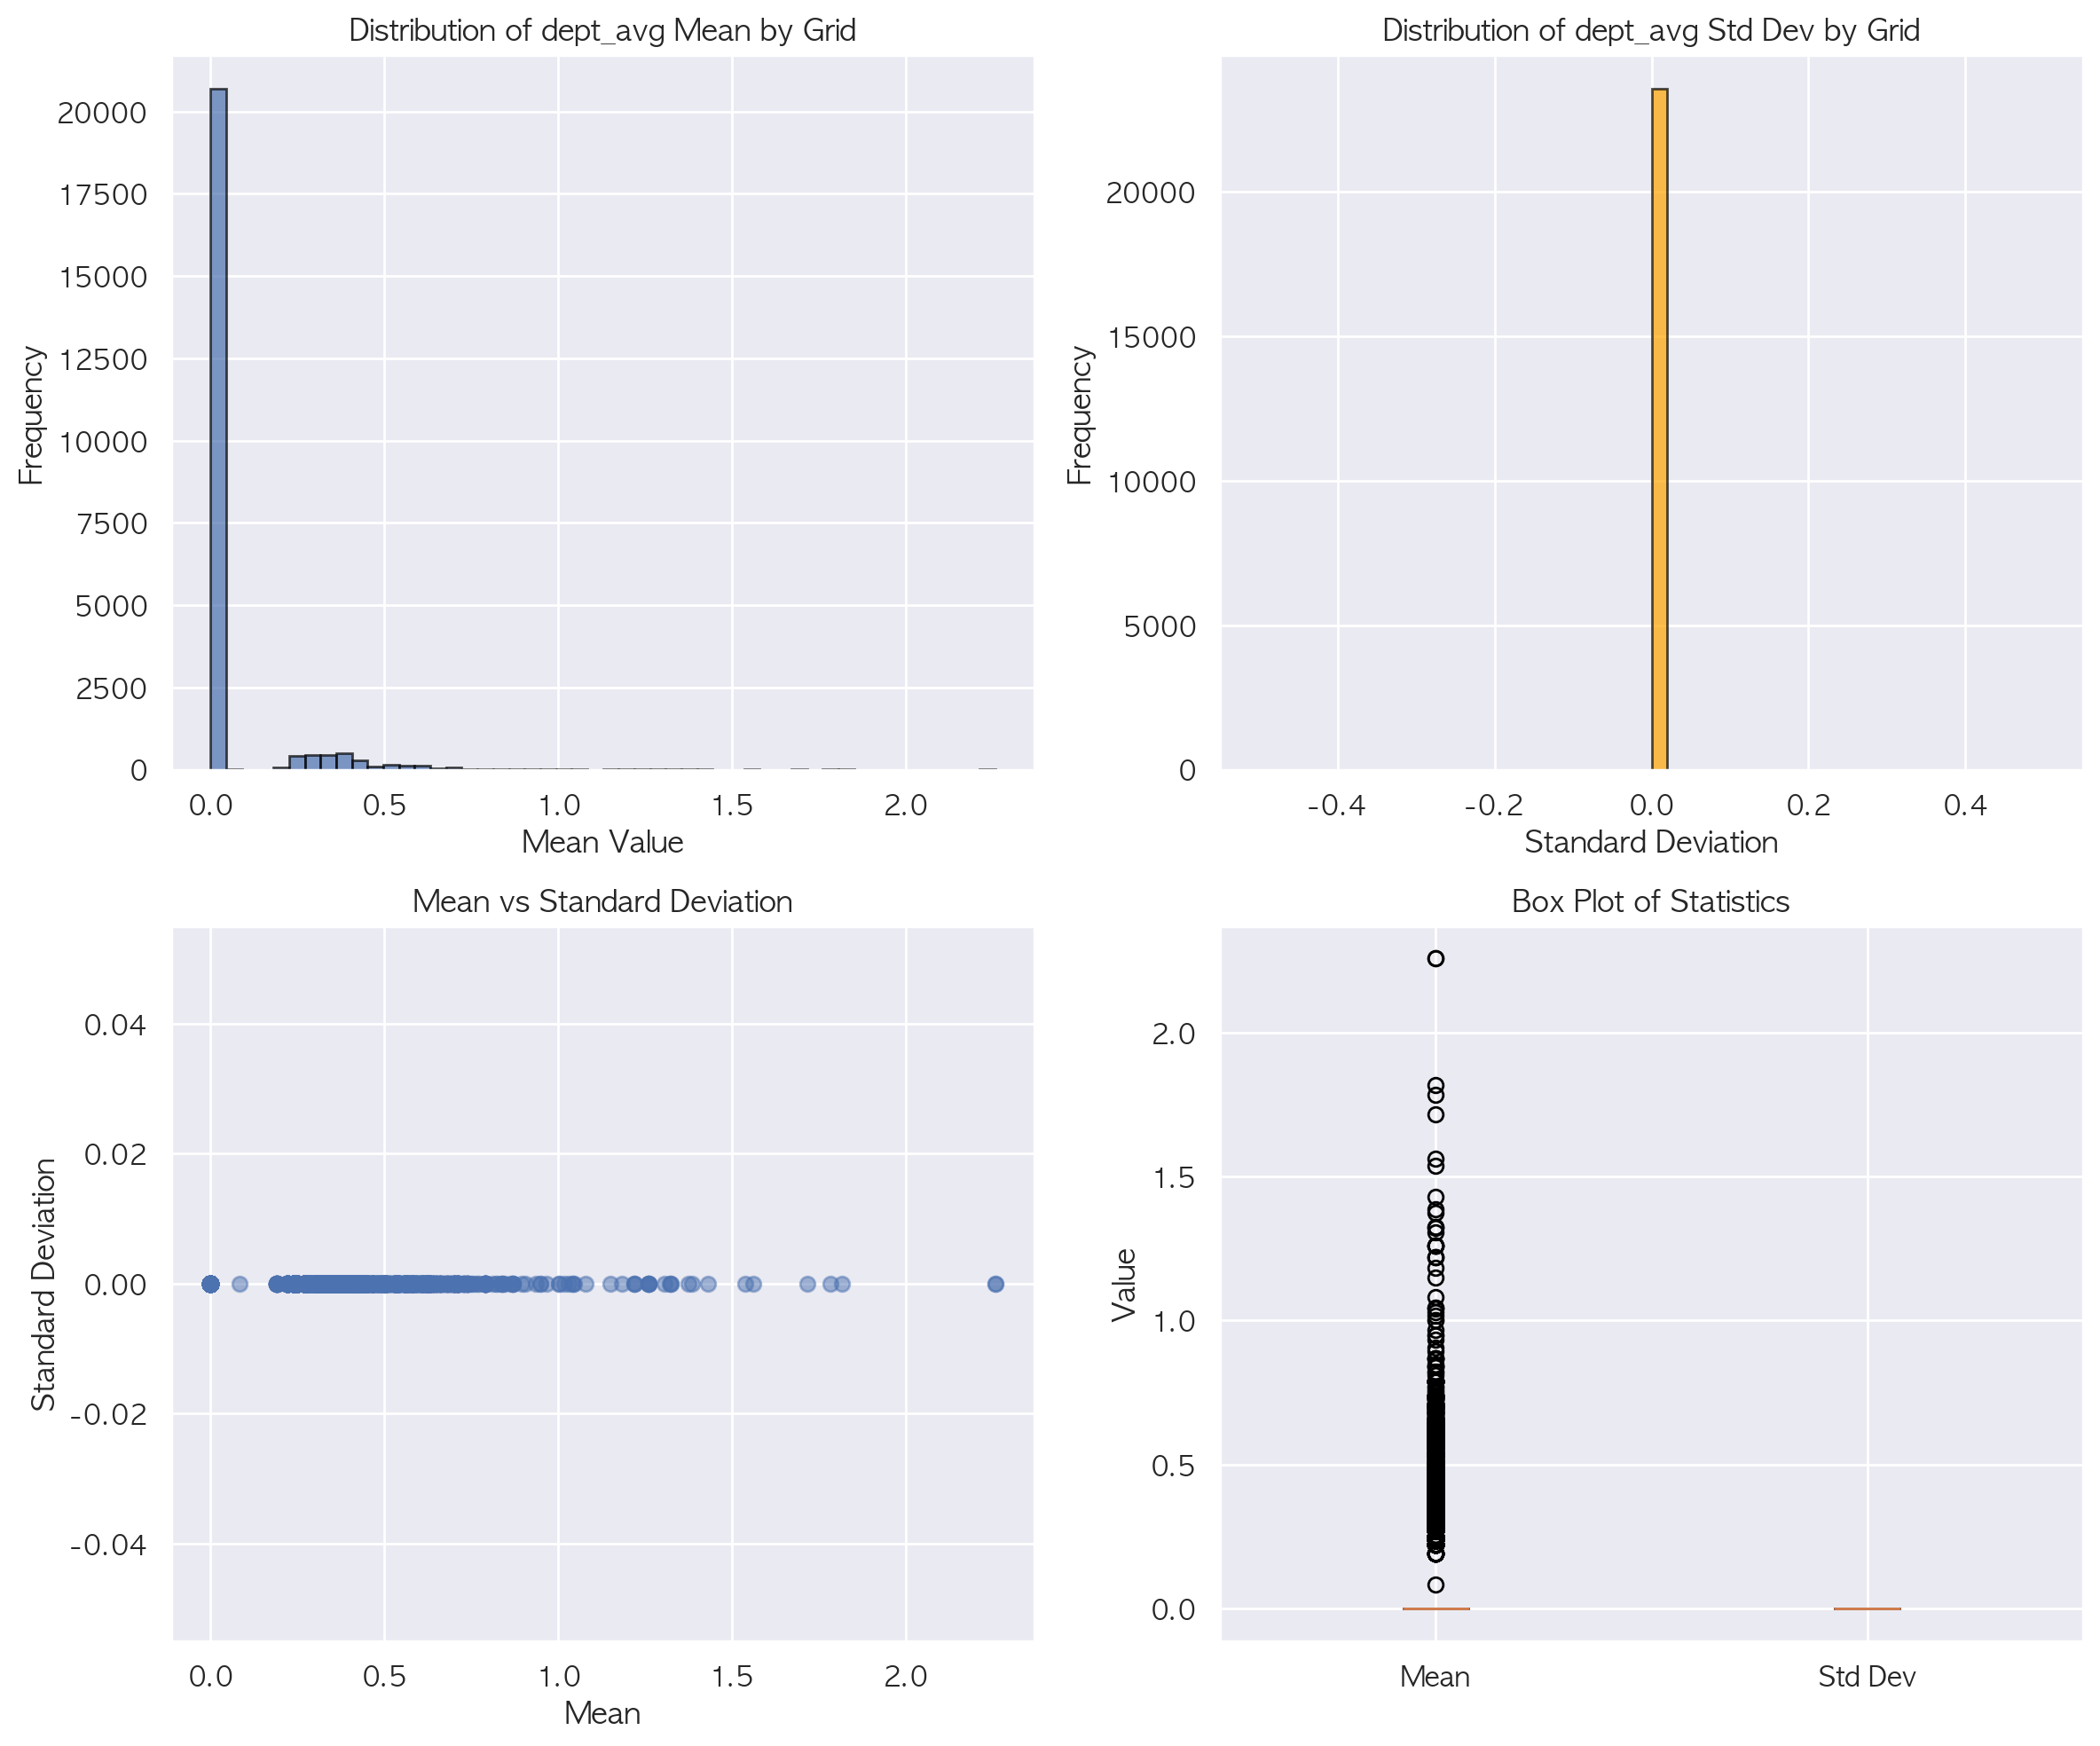


💾 통계 결과 저장됨: /Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/100grid/grid_flooded_area_statistics.csv

🌊 침수 그리드 분석:
- 침수된 그리드: 2,872 (12.2%)
- 침수되지 않은 그리드: 20,692 (87.8%)


In [27]:
# ─── Flooded_area 그리드별 통계 분석 ───

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) 데이터 로드
df = pd.read_csv('/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/파이선 코드/SCI/100grid/SCI_100grid_flood_risk_data.csv')

# 2) 데이터 구조 확인
print("📊 데이터셋 정보:")
print(f"- 전체 행 수: {len(df):,}")
print(f"- 전체 열 수: {len(df.columns)}")
print("\n📋 컬럼 목록:")
print(df.columns.tolist())

# 3) Flooded_area 관련 컬럼 찾기
# 'Flooded_area' 또는 유사한 이름의 컬럼 찾기
flooded_cols = [col for col in df.columns if 'flood' in col.lower() or 'area' in col.lower()]
print(f"\n🔍 Flood/Area 관련 컬럼: {flooded_cols}")

# 만약 정확한 컬럼명이 없다면, dept_avg를 사용하거나 사용자에게 확인 요청
if 'Flooded_area' in df.columns:
    target_col = 'Flooded_area'
elif 'flooded_area' in df.columns:
    target_col = 'flooded_area'
else:
    print("\n⚠️ 'Flooded_area' 컬럼을 찾을 수 없습니다.")
    print("사용 가능한 컬럼 중 관련된 것을 선택해주세요:")
    # dept_avg가 침수 깊이라면 이를 사용할 수도 있음
    if 'dept_avg' in df.columns:
        print("'dept_avg' 컬럼을 사용하여 분석을 진행합니다.")
        target_col = 'dept_avg'
    else:
        # 실제 컬럼명 확인 필요
        print("데이터의 첫 5개 컬럼:", df.columns[:5].tolist())
        target_col = None

if target_col:
    # 4) 그리드 식별 컬럼 찾기
    # 일반적으로 'grid_id', 'GRID_ID', 'id', 'FID' 등의 이름 사용
    grid_cols = [col for col in df.columns if 'grid' in col.lower() or col.lower() in ['id', 'fid', 'objectid']]
    print(f"\n🔍 그리드 관련 컬럼: {grid_cols}")
    
    # 그리드 ID 컬럼 선택 (없으면 인덱스 사용)
    if grid_cols:
        grid_id_col = grid_cols[0]
        print(f"사용할 그리드 ID 컬럼: {grid_id_col}")
    else:
        # 그리드 ID가 없으면 인덱스를 그리드 ID로 사용
        df['grid_id'] = df.index
        grid_id_col = 'grid_id'
        print("그리드 ID 컬럼이 없어 인덱스를 사용합니다.")
    
    # 5) 각 그리드별 통계 계산
    print(f"\n📈 각 그리드별 {target_col} 통계 계산 중...")
    
    # 그리드별 그룹화 및 통계 계산
    grid_stats = df.groupby(grid_id_col)[target_col].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('min', 'min'),
        ('max', 'max'),
        ('count', 'count'),
        ('sum', 'sum')
    ]).reset_index()
    
    # NaN 값을 0으로 대체 (std가 NaN인 경우는 단일 값만 있는 경우)
    grid_stats['std'] = grid_stats['std'].fillna(0)
    
    # 6) 결과 출력
    print(f"\n📊 그리드별 {target_col} 통계 요약:")
    print(f"- 총 그리드 수: {len(grid_stats):,}")
    print(f"- 평균의 평균: {grid_stats['mean'].mean():.4f}")
    print(f"- 평균의 표준편차: {grid_stats['mean'].std():.4f}")
    print(f"- 표준편차의 평균: {grid_stats['std'].mean():.4f}")
    
    # 상위 10개 그리드 표시
    print(f"\n🔝 {target_col} 평균이 높은 상위 10개 그리드:")
    top_10 = grid_stats.nlargest(10, 'mean')
    print(top_10[[grid_id_col, 'mean', 'std', 'count']])
    
    # 7) 시각화
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 평균값 분포
    axes[0, 0].hist(grid_stats['mean'], bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title(f'Distribution of {target_col} Mean by Grid')
    axes[0, 0].set_xlabel('Mean Value')
    axes[0, 0].set_ylabel('Frequency')
    
    # 표준편차 분포
    axes[0, 1].hist(grid_stats['std'], bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[0, 1].set_title(f'Distribution of {target_col} Std Dev by Grid')
    axes[0, 1].set_xlabel('Standard Deviation')
    axes[0, 1].set_ylabel('Frequency')
    
    # 평균 vs 표준편차 산점도
    axes[1, 0].scatter(grid_stats['mean'], grid_stats['std'], alpha=0.5)
    axes[1, 0].set_title('Mean vs Standard Deviation')
    axes[1, 0].set_xlabel('Mean')
    axes[1, 0].set_ylabel('Standard Deviation')
    
    # 박스플롯
    axes[1, 1].boxplot([grid_stats['mean'], grid_stats['std']], 
                       labels=['Mean', 'Std Dev'])
    axes[1, 1].set_title('Box Plot of Statistics')
    axes[1, 1].set_ylabel('Value')
    
    plt.tight_layout()
    plt.show()
    
    # 8) 결과 저장
    output_path = '/Users/justcallme_jo/Library/CloudStorage/GoogleDrive-agijuju007@gmail.com/.shortcut-targets-by-id/1Rookh1ECtS7QwJYyFtDQsrm0ZpWubpyI/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/100grid'
    stats_file = f'{output_path}/grid_flooded_area_statistics.csv'
    grid_stats.to_csv(stats_file, index=False)
    print(f"\n💾 통계 결과 저장됨: {stats_file}")
    
    # 9) 추가 분석: 침수/비침수 그리드 비율
    if target_col == 'dept_avg':
        flooded_grids = (grid_stats['mean'] > 0).sum()
        total_grids = len(grid_stats)
        print(f"\n🌊 침수 그리드 분석:")
        print(f"- 침수된 그리드: {flooded_grids:,} ({flooded_grids/total_grids*100:.1f}%)")
        print(f"- 침수되지 않은 그리드: {total_grids-flooded_grids:,} ({(total_grids-flooded_grids)/total_grids*100:.1f}%)")

else:
    print("\n❌ 분석을 수행할 수 없습니다. 정확한 컬럼명을 확인해주세요.")
    print("\n사용 가능한 모든 컬럼:")
    for i, col in enumerate(df.columns):
        print(f"{i}: {col}")